# 신용 승인 정책 고도화를 위한 리스크 예측 모델 & 실험 설계

## step 1) 가설 기반 EDA 코드

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.unicode_minus"] = False

# 0) Load & basic sanity check
df = pd.read_csv('german_credit.csv')

print(" Loaded:", df.shape)
print(df.head(3))

# 컬럼 표준화(공백/대소문자 흔들릴 수 있어서 안전하게 처리하기 위함)
df.columns = [c.strip() for c in df.columns]

# 불필요 인덱스 컬럼 제거
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
    print(" Dropped 'Unnamed: 0'")

# Risk label 확인: good/bad 형태 가정
target_col = "Risk"
assert target_col in df.columns, f"'{target_col}' column not found. columns={df.columns.tolist()}"

 Loaded: (1000, 11)
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   

   Credit amount  Duration    Purpose  Risk  
0           1169         6   radio/TV  good  
1           5951        48   radio/TV   bad  
2           2096        12  education  good  
 Dropped 'Unnamed: 0'


In [2]:
# y=1: bad (should be rejected), y=0: good (can be approved)
def make_y_bad(df, col="Risk"):
    return df[col].str.lower().map({"good": 0, "bad": 1}).astype(int)

In [3]:
# Utils: policy / threshold / KPI

import numpy as np
import pandas as pd
from math import ceil

# 1) Rule-based policy helpers (Control)
def rule_policy_approve(df_scored: pd.DataFrame) -> pd.Series:
    """
    Current policy example:
    - approve if Credit_Rating in [Medium, High, Very High]
    - reject if Low
    """
    return df_scored["Credit_Rating"].isin(["Medium", "High", "Very High"]).astype(int)

def bad_approval_rate_from_policy(y_true_bad, approve_pred) -> float:
    """
    y_true_bad: 1=bad, 0=good
    approve_pred: 1=approve, 0=reject
    """
    y_true_bad = np.array(y_true_bad).astype(int)
    approved = (np.array(approve_pred) == 1)
    if approved.sum() == 0:
        return np.nan
    bad_approved = ((y_true_bad == 1) & approved).sum()
    return bad_approved / approved.sum()

def policy_metrics_from_approve(y_true_bad, approve_pred, gain=1.0, loss=5.0) -> dict:
    """
    Policy-level KPI from approve/reject decisions.
    """
    y_true_bad = np.array(y_true_bad).astype(int)
    approved = (np.array(approve_pred) == 1)

    approved_cnt = int(approved.sum())
    bad_approved_cnt = int(((y_true_bad == 1) & approved).sum())

    approval_rate = approved_cnt / len(y_true_bad)
    bad_approval_rate = bad_approved_cnt / approved_cnt if approved_cnt else np.nan

    expected_profit = approved_cnt * gain - bad_approved_cnt * loss
    expected_profit_per_approval = expected_profit / approved_cnt if approved_cnt else np.nan

    return {
        "approval_rate": float(approval_rate),
        "bad_approval_rate": float(bad_approval_rate) if approved_cnt else np.nan,
        "approved_cnt": approved_cnt,
        "bad_approved_cnt": bad_approved_cnt,
        "expected_profit": float(expected_profit),
        "expected_profit_per_approval": float(expected_profit_per_approval) if approved_cnt else np.nan,
    }

# 2) Threshold helpers (Treatment)
def approve_from_proba(proba: np.ndarray, threshold: float) -> np.ndarray:
    """
    Convention: proba = P(bad)
    Reject if proba >= threshold
    Approve if proba < threshold
    Returns: 1=approve, 0=reject
    """
    proba = np.array(proba)
    return (proba < threshold).astype(int)

def bad_approval_rate_at_threshold(y_true_bad, proba, threshold: float) -> float:
    """
    bad approval rate among approved under threshold policy.
    """
    approve_pred = approve_from_proba(proba, threshold)
    return bad_approval_rate_from_policy(y_true_bad, approve_pred)

# # 3) Sample size helper
def needed_total_inflow(n_per_group: int, treatment_share: float) -> int:
    """
    If treatment is the bottleneck: treatment_share * N_total >= n_per_group
    """
    return int(ceil(n_per_group / treatment_share))


[Class Distribution]
      count  ratio
Risk              
good    700    0.7
bad     300    0.3


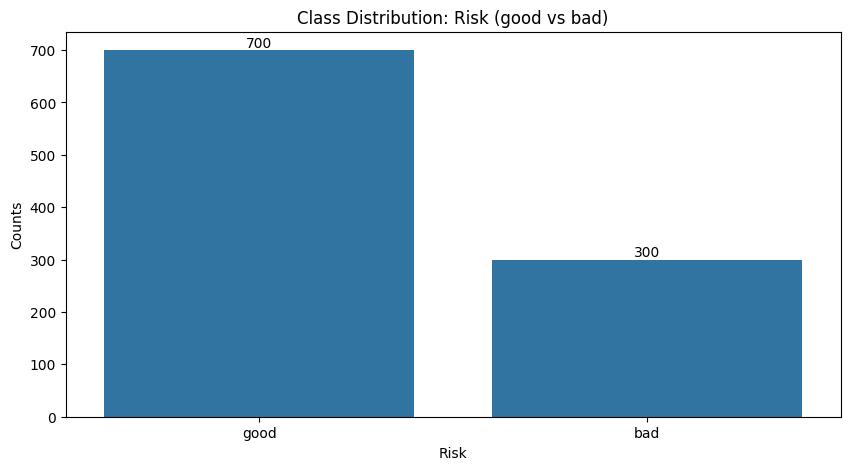

In [4]:
# 1) Class balance (Good/Bad)
risk_counts = df[target_col].value_counts(dropna=False)
risk_ratio = (risk_counts / len(df)).round(3)

print("\n[Class Distribution]")
print(pd.DataFrame({"count": risk_counts, "ratio": risk_ratio}))

plt.figure()
ax = sns.countplot(data=df, x=target_col, order=risk_counts.index)
plt.title("Class Distribution: Risk (good vs bad)")
plt.xlabel("Risk")
plt.ylabel("Counts")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()), 
                ha="center", va="bottom", fontsize=10)
plt.show()

In [5]:
# 2) Missingness: heatmap + missing rate
missing_cnt = df.isna().sum().sort_values(ascending=False)
missing_rate = (missing_cnt / len(df)).sort_values(ascending=False)

missing_df = pd.DataFrame({"missing_cnt": missing_cnt, "missing_rate": missing_rate}).query("missing_cnt > 0")
print("\n[Missing Summary]")
print(missing_df)


[Missing Summary]
                  missing_cnt  missing_rate
Checking account          394         0.394
Saving accounts           183         0.183


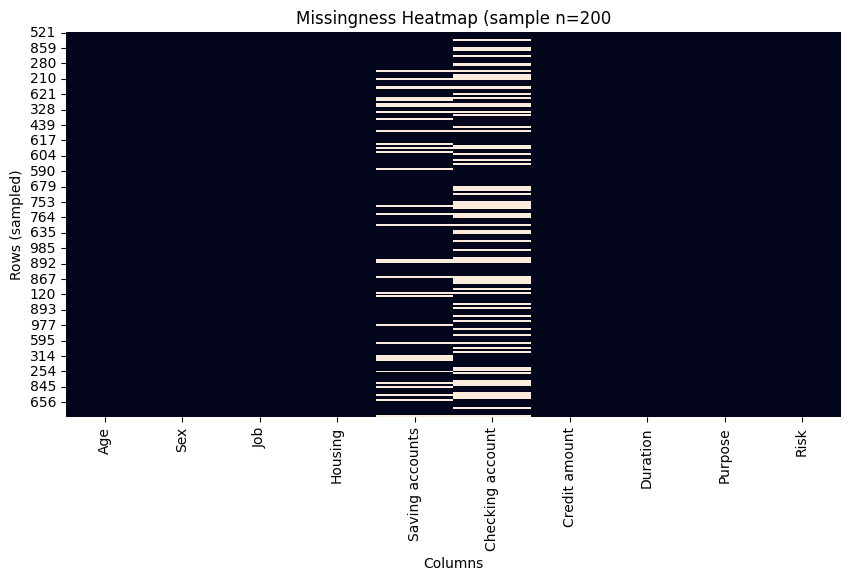

In [6]:
# 2) - (A) Missing heatmap (행이 많아 전체를 그리면 과하게 느릴 수 있어서 샘플링)
sample_n = min(200, len(df))
sample_df = df.sample(sample_n, random_state=42)

plt.figure(figsize=(10, 5))
sns.heatmap(sample_df.isna(), cbar=False)
plt.title(f"Missingness Heatmap (sample n={sample_n}")
plt.xlabel("Columns")
plt.ylabel("Rows (sampled)")
plt.show()

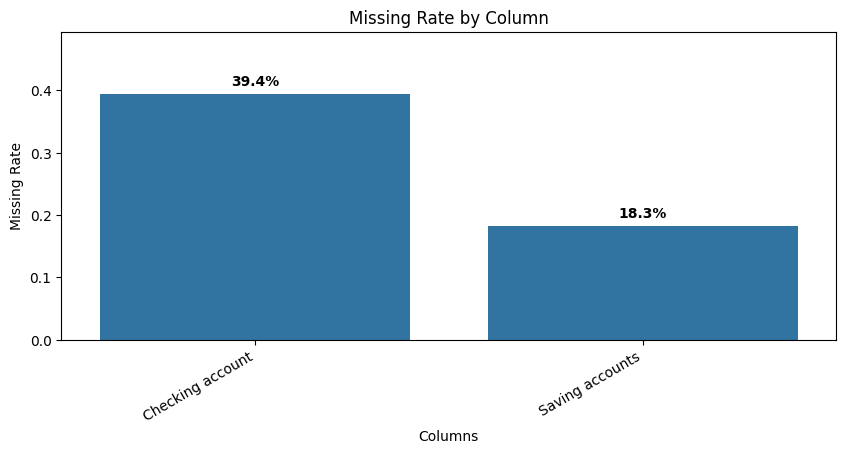

In [17]:
# 2) - (B) Missing rate bar
if len(missing_df) > 0:
    plt.figure(figsize=(10, 4))
    ax = sns.barplot(x=missing_df.index, y=missing_df["missing_rate"])
    
    # 막대 상단에 비율 숫자 표시
    for p in ax.patches:
        ax.annotate(f'{p.get_height() * 100:.1f}%', # 100을 곱해 %로 변환
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

    plt.title("Missing Rate by Column")
    plt.ylabel("Missing Rate")
    plt.xlabel("Columns")
    plt.xticks(rotation=30, ha="right")
    
    # 텍스트가 잘리지 않도록 y축 상단 여유 확보
    plt.ylim(0, min(1.0, missing_df["missing_rate"].max() + 0.1)) 
    plt.show()

In [8]:
# 3) Hypothesis setup: create helper columns for EDA only
# Age_group은 가설 검증(연령대) 시각화에 필요하니 우선 생성(결측 없어야 함)
# 구간: Student(18-25), Young(26-35), Adult(36-60), Senior(60+)

age_col = "Age"
assert age_col in df.columns, f"'{age_col}' column not found."

bins = [0, 25, 35, 60, np.inf]
labels = ["Student(<=25)", "Young(26-35)", "Adult(36-60)", "Senior(60+)"]
df["Age_group"] = pd.cut(df[age_col], bins=bins, labels=labels, right=True)

# Bad = 1, Good = 0(bad rate 계산용)
df["is_bad"] = (df[target_col].str.lower() == "bad").astype(int)

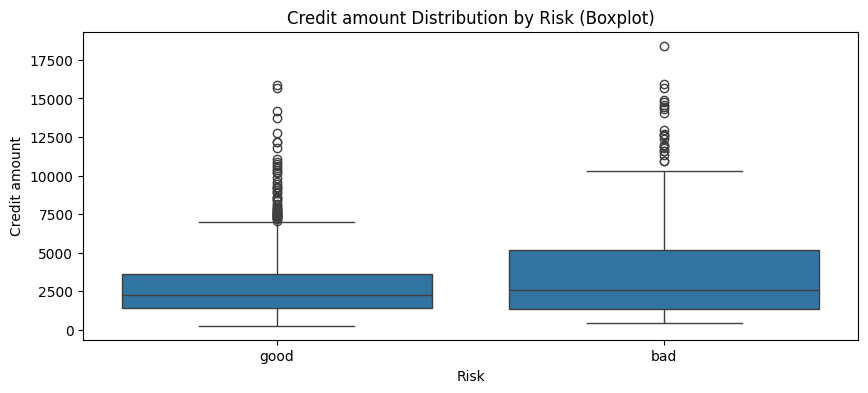

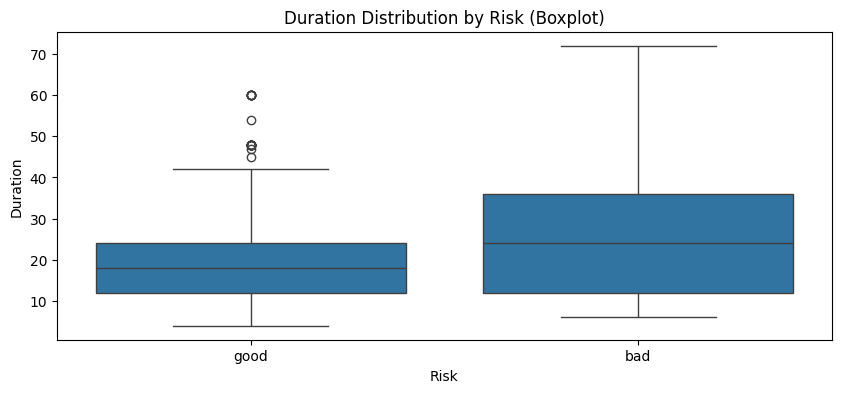

In [9]:
# 4) Risk별 Credit amount / Duration 분포
num_cols = ["Credit amount", "Duration"]
for c in num_cols:
    if c not in df.columns:
        raise ValueError(f"'{c}' column not found. columns={df.columns.tolist()}")

for c in num_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x=target_col, y=c, order=["good", "bad"] if set(df[target_col].unique()) >= {"good","bad"} else None)
    plt.title(f"{c} Distribution by Risk (Boxplot)")
    plt.xlabel("Risk")
    plt.ylabel(c)
    plt.show()

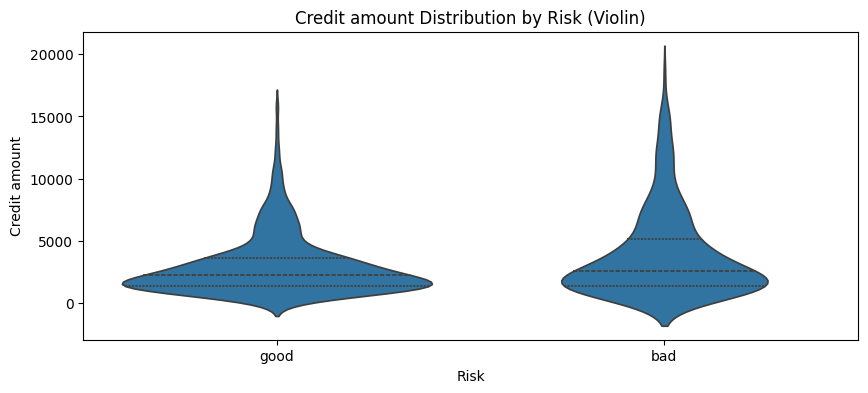

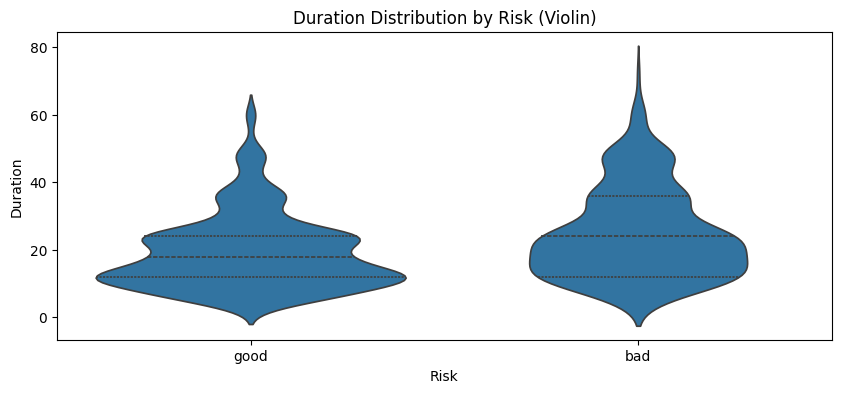

In [10]:
# 추가 바이올린 형태
for c in num_cols:
    plt.figure(figsize=(10, 4))
    sns.violinplot(data=df, x=target_col, y=c, inner="quartile",
                   order=["good", "bad"] if set(df[target_col].unique()) >= {"good","bad"} else None)
    plt.title(f"{c} Distribution by Risk (Violin)")
    plt.xlabel("Risk")
    plt.ylabel(c)
    plt.show()

고액 + 장기 대출 구간에서 리스크 확대 가능성


[Bad rate by Purpose]
               Purpose  count  bad_rate
7      vacation/others     12  0.416667
3            education     59  0.389831
6              repairs     22  0.363636
0             business     97  0.350515
2  domestic appliances     12  0.333333
4  furniture/equipment    181  0.320442
1                  car    337  0.314540
5             radio/TV    280  0.221429


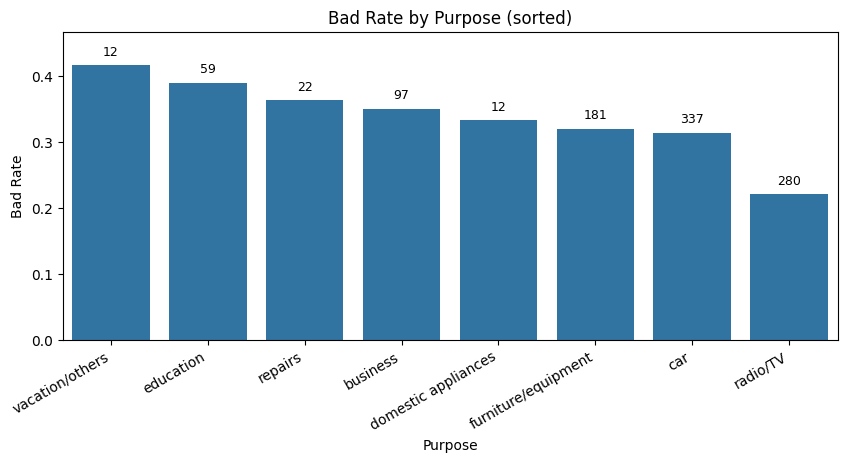


[Bad rate by Housing]
  Housing  count  bad_rate
0    free    108  0.407407
2    rent    179  0.391061
1     own    713  0.260870


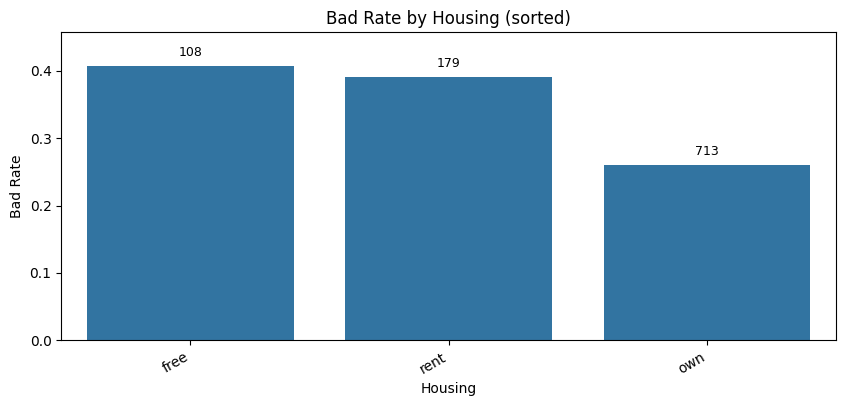


[Bad rate by Job]
   Job  count  bad_rate
3    3    148  0.344595
0    0     22  0.318182
2    2    630  0.295238
1    1    200  0.280000


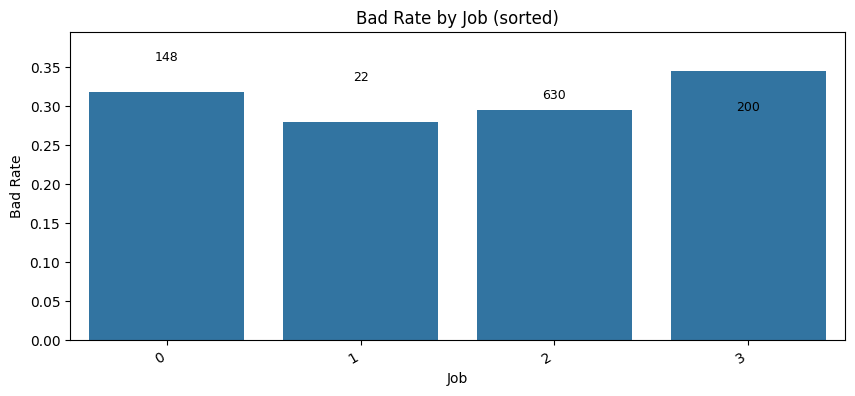

In [11]:
# 5) Categorical levers: Purpose / Housing / Job별 bad 비율
# 정책을 어디에 적용할지 후보 찾기에 유용

cat_cols = ["Purpose", "Housing", "Job"]

for col in cat_cols:
    if col not in df.columns:
        raise ValueError(f"'{col}' column not found. columns={df.columns.tolist()}")

def plot_bad_rate_sorted(data: pd.DataFrame, col: str):
    grp = data.groupby(col)["is_bad"].agg(["mean", "count"]).reset_index()
    grp = grp.sort_values("mean", ascending=False)
    grp["bad_rate"] = grp["mean"]

    print(f"\n[Bad rate by {col}]")
    print(grp[[col, "count", "bad_rate"]].head(20))

    plt.figure(figsize=(10, 4))
    sns.barplot(data=grp, x=col, y="bad_rate")
    plt.title(f"Bad Rate by {col} (sorted)")
    plt.ylabel("Bad Rate")
    plt.xlabel(col)
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, min(1.0, grp["bad_rate"].max() + 0.05))
    # 표본 수 같이 표시
    for i, row in grp.iterrows():
        plt.text(x=list(grp[col]).index(row[col]), y=row["bad_rate"] + 0.01, s=int(row["count"]),
                 ha="center", va="bottom", fontsize=9)
    plt.show()

for col in cat_cols:
    plot_bad_rate_sorted(df, col)

- 승인 정책을 동일하게 적용하면 안 됨.
- “목적 기반 차등 승인 전략”이 가능
- 자가 소유 고객은 리스크가 확실히 낮다.


[Risk % by Age_group]
Risk             bad   good
Age_group                  
Student(<=25)  42.11  57.89
Young(26-35)   29.65  70.35
Adult(36-60)   25.07  74.93
Senior(60+)    22.22  77.78


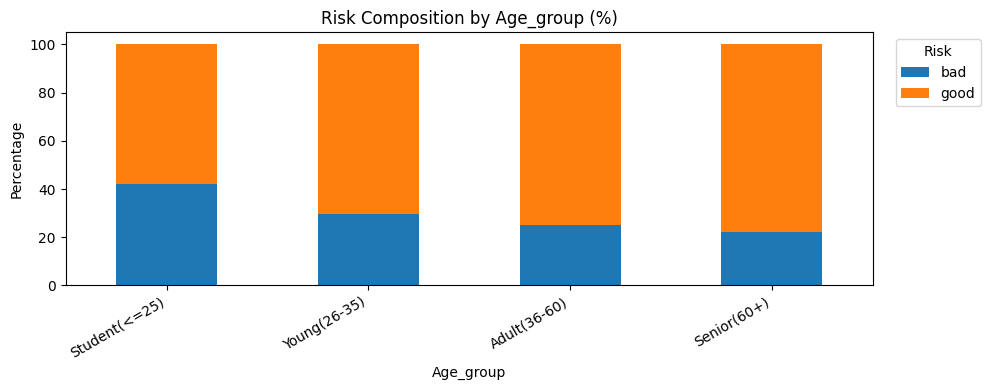


[Risk % by Job]
Risk    bad   good
Job               
3     34.46  65.54
0     31.82  68.18
2     29.52  70.48
1     28.00  72.00


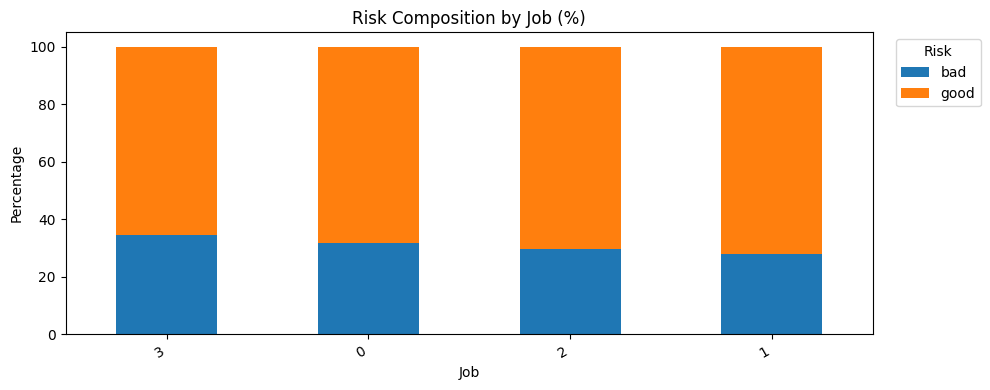

In [12]:
# 6) Age_group / Job 수준별 Risk 구성비 - 가설 검증용

def plot_stacked_risk_pct(data: pd.DataFrame, group_col: str):
    tab = pd.crosstab(data[group_col], data[target_col], normalize="index") * 100
    tab = tab.sort_values(by="bad", ascending=False) if "bad" in tab.columns else tab
    print(f"\n[Risk % by {group_col}]")
    print(tab.round(2))

    tab.plot(kind="bar", stacked=True, figsize=(10, 4))
    plt.title(f"Risk Composition by {group_col} (%)")
    plt.ylabel("Percentage")
    plt.xlabel(group_col)
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Risk", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_stacked_risk_pct(df, "Age_group")
plot_stacked_risk_pct(df, "Job")

25세 이하 Student는 거의 free housing 수준 리스크

## step 2) 전처리 + FE + 룰 기반 정책 성능 비교

In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [14]:
# 0) Load

df = pd.read_csv('german_credit.csv')
df.columns = [c.strip() for c in df.columns]

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

target_col = "Risk"
df[target_col] = df[target_col].str.lower()

Original: (1000, 10)
dropna(subset=['Saving accounts', 'Checking account']): (522, 10)


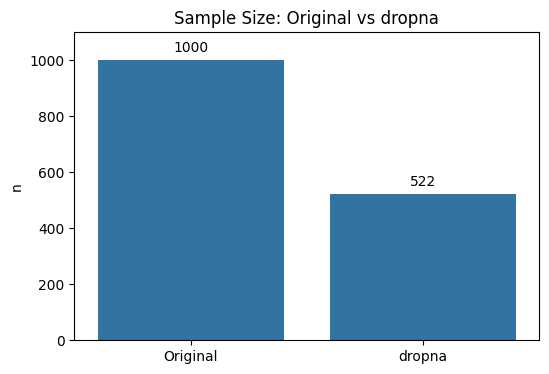

In [15]:
# 1) dropna 시 샘플 수 확인
need_cols = ["Saving accounts", "Checking account"]
for c in need_cols:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")

df_dropna = df.dropna(subset=need_cols).copy()

print("Original:", df.shape)
print("dropna(subset=['Saving accounts', 'Checking account']):", df_dropna.shape)

# 샘플 수 비교 시각화
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=["Original", "dropna"], y=[len(df), len(df_dropna)])

# 막대 상단에 숫자 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.title("Sample Size: Original vs dropna")
plt.ylabel("n")
plt.ylim(0, max(len(df), len(df_dropna)) * 1.1) # 텍스트가 잘리지 않게 y축 여유 조절
plt.show()

In [18]:
# 2) Age_group 생성 (결측치 대체 그룹 키로 사용)

age_col = "Age"
bins = [0, 25, 35, 60, np.inf]
labels = ["Student(<=25)", "Young(26-35)", "Adult(36-60)", "Senior(60+)"]

df["Age_group"] = pd.cut(df[age_col], bins=bins, labels=labels, right=True)

C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\4028716103.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(keys)[col]
C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\4028716103.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(keys)[col]


✅ Impute Saving accounts: 183 -> 0
✅ Impute Checking account: 394 -> 0


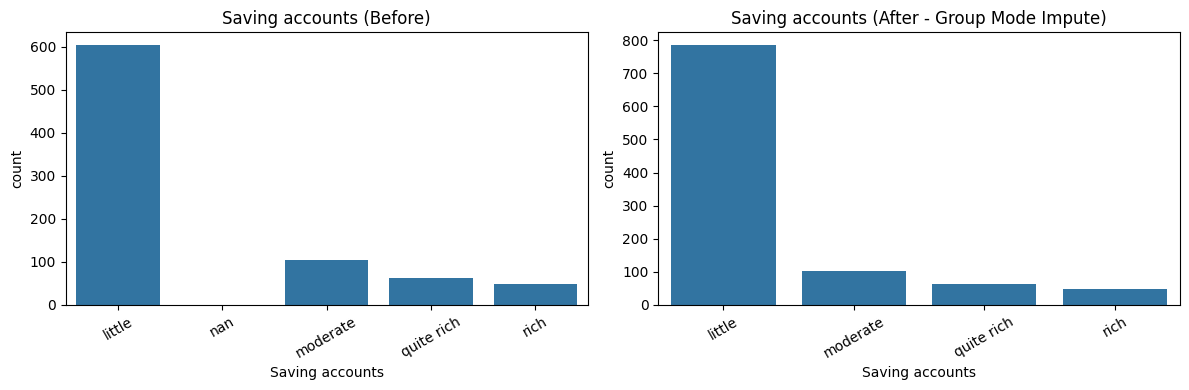

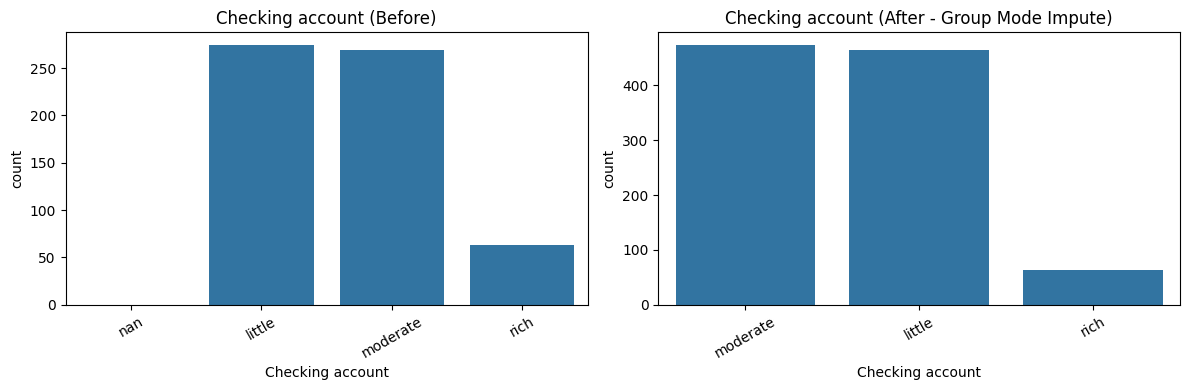

In [19]:
# 3) 그룹 기반 최빈값 대체 함수
#    Age_group × Job × Housing 그룹별 mode로 채우고
#    그래도 남으면 전체 mode로 fallback

group_keys = ["Age_group", "Job", "Housing"]

for k in group_keys:
    if k not in df.columns:
        raise ValueError(f"Missing group key column: {k}")

def fill_mode_by_group(data: pd.DataFrame, col: str, keys: list) -> pd.Series:
    """group mode로 결측 채움, 남으면 전체 mode로 채움"""
    s = data[col].copy()

    # 그룹별 mode 계산
    mode_map = (
        data.groupby(keys)[col]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )

    # 결측인 행에 대해서 그룹 mode로 채우기
    miss_idx = s[s.isna()].index
    if len(miss_idx) > 0:
        for idx in miss_idx:
            key = tuple(data.loc[idx, keys])
            if key in mode_map.index and pd.notna(mode_map.loc[key]):
                s.loc[idx] = mode_map.loc[key]

    # 그래도 남으면 전체 mode로
    if s.isna().any():
        global_mode = data[col].mode().iloc[0]
        s = s.fillna(global_mode)

    return s

df_imputed = df.copy()
for col in ["Saving accounts", "Checking account"]:
    before = df_imputed[col].isna().sum()
    df_imputed[col] = fill_mode_by_group(df_imputed, col, group_keys)
    after = df_imputed[col].isna().sum()
    print(f"✅ Impute {col}: {before} -> {after}")

# 결측치 처리 전/후 분포 비교 (Saving/Checking)
for col in ["Saving accounts", "Checking account"]:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.countplot(data=df, x=col, ax=axes[0], order=df[col].value_counts(dropna=False).index)
    axes[0].set_title(f"{col} (Before)")
    axes[0].tick_params(axis="x", rotation=30)

    sns.countplot(data=df_imputed, x=col, ax=axes[1], order=df_imputed[col].value_counts().index)
    axes[1].set_title(f"{col} (After - Group Mode Impute)")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

In [20]:
# 4) Feature Engineering
#    Credit_ratio = Credit amount / Duration

for c in ["Credit amount", "Duration"]:
    if c not in df_imputed.columns:
        raise ValueError(f"Missing column: {c}")

df_imputed["Credit_ratio"] = df_imputed["Credit amount"] / df_imputed["Duration"]

In [21]:
# 5) 룰 기반 Score 생성

# (A) Baseline: dropna 버전(522건)
df_base = df.copy()
df_base["Credit_ratio"] = df_base["Credit amount"] / df_base["Duration"]

df_base_drop = df_base.dropna(subset=["Saving accounts", "Checking account"]).copy()
print("Baseline(dropna) shape:", df_base_drop.shape)  # 522 기대

Baseline(dropna) shape: (522, 12)


In [22]:
df_raw_for_model = df.copy()
df_raw_for_model["Credit_ratio"] = df_raw_for_model["Credit amount"] / df_raw_for_model["Duration"]
# Age_group이 Step2에서 이미 만들어졌다면 df_raw_for_model에도 존재함
df_raw_for_model["Age_group"] = df["Age_group"]

# (B) Improved: 그룹 최빈값 대체
df_imp = df.copy()
df_imp["Credit_ratio"] = df_imp["Credit amount"] / df_imp["Duration"]

group_keys = ["Age_group", "Job", "Housing"]

def fill_mode_by_group(data: pd.DataFrame, col: str, keys: list) -> pd.Series:
    s = data[col].copy()
    mode_map = (
        data.groupby(keys)[col]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    miss_idx = s[s.isna()].index
    for idx in miss_idx:
        key = tuple(data.loc[idx, keys])
        if key in mode_map.index and pd.notna(mode_map.loc[key]):
            s.loc[idx] = mode_map.loc[key]
    if s.isna().any():
        s = s.fillna(data[col].mode().iloc[0])
    return s

for col in ["Saving accounts", "Checking account"]:
    df_imp[col] = fill_mode_by_group(df_imp, col, group_keys)

print("Improved(imputed) shape:", df_imp.shape)

C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\143874411.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(keys)[col]
C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\143874411.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(keys)[col]


Improved(imputed) shape: (1000, 12)


In [23]:
# (C) 룰 기반 Score 계산
saving_map   = {'little': 4, 'moderate': 3, 'quite rich': 2, 'rich': 1}
checking_map = {'little': 3, 'moderate': 2, 'rich': 1}
housing_map  = {'free': 5, 'rent': 3, 'own': 1}
purpose_map  = {'radio/TV': 1, 'furniture/equipment': 1, 'car': 1,
                'education': 0, 'business': 0, 'repairs': 0,
                'domestic appliances': 0, 'vacation/others': 0}
age_score_map = {"Student": 20, "Young": 15, "Adult": 10, "Senior": 5}

def add_score_and_rating(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    out["Age_group_base"] = (
        out["Age_group"].astype(str).str.replace(r"\(.*\)", "", regex=True).str.strip()
    )

    out["Saving_m"]   = out["Saving accounts"].map(saving_map)
    out["Checking_m"] = out["Checking account"].map(checking_map)
    out["Housing_m"]  = out["Housing"].map(housing_map)
    out["Purpose_m"]  = out["Purpose"].map(purpose_map)
    out["Age_m"]      = out["Age_group_base"].map(age_score_map)

    # 혹시 매핑 누락 있으면 바로 확인
    missing_maps = out[["Saving_m","Checking_m","Housing_m","Purpose_m","Age_m"]].isna().sum()
    if missing_maps.any():
        print("⚠️ mapping NaN counts:\n", missing_maps)

    out["Score"] = (
        out["Saving_m"] * 10
        + out["Checking_m"] * 10
        + out["Housing_m"] * 3
        + out["Job"] * 3
        + np.where(out["Purpose_m"] == 1, 10, 0)
        + out["Age_m"]
        + out["Credit_ratio"] / 100
    )

    # 원본 맥락: Score 분위로 Rating (1~4)
    bins = [0, 0.3, 0.5, 0.9, 1.0]
    out["Credit_Rating"] = pd.qcut(
        out["Score"].rank(method="first") / len(out),
        q=[0,0.3,0.5,0.9,1.0],
        labels=["Low","Medium","High","Very High"]
    )
    return out

df_base_drop = add_score_and_rating(df_base_drop)
df_imp = add_score_and_rating(df_imp)

In [24]:
# (D) Rating 기반 정책 예측

def predict_from_rating(rating_series):
    return rating_series.map({
        "Low": 0,
        "Medium": 1,
        "High": 1,
        "Very High": 1
    })

def eval_policy_full(data: pd.DataFrame, title: str):

    y_true = data["Risk"].str.lower().map({"bad": 0, "good": 1}).astype(int)

    y_pred = data["Credit_Rating"].map({
        "Low": 1,
        "Medium": 1,
        "High": 1,
        "Very High": 0
    }).astype(int)

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])

    print(f"\n[{title}]")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", cm)
    return acc, cm

In [25]:
acc_base, cm_base = eval_policy_full(df_base_drop, "Baseline (dropna)")
acc_imp,  cm_imp  = eval_policy_full(df_imp, "Improved (group-mode impute)")


[Baseline (dropna)]
Accuracy: 0.5709
Confusion Matrix:
 [[ 30 201]
 [ 23 268]]

[Improved (group-mode impute)]
Accuracy: 0.6840
Confusion Matrix:
 [[ 42 258]
 [ 58 642]]


- 결측치를 단순 제거(dropna)한 경우 정책 정확도는 57.1%였지만, Age_group × Job × Housing 기반 그룹 최빈값 대체 전략을 적용한 경우 정확도는 68.4%까지 개선되었다.
- 이는 데이터 삭제보다 구조적 결측 보완 전략이 정책 성능을 크게 향상시킨다는 것을 보여준다.

In [26]:
print(df_imp.groupby("Credit_Rating")["Risk"].value_counts(normalize=True))

Credit_Rating  Risk
Low            good    0.783333
               bad     0.216667
Medium         good    0.710000
               bad     0.290000
High           good    0.662500
               bad     0.337500
Very High      good    0.580000
               bad     0.420000
Name: proportion, dtype: float64


C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\4208126670.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_imp.groupby("Credit_Rating")["Risk"].value_counts(normalize=True))


- Score를 분위 기반으로 4개 구간(Low / Medium / High / Very High)으로 나누어 Risk Tier를 생성하였다.
- 여기서 Score는 신용도가 아니라 리스크 점수(Risk score)로 설계되었기 때문에, 값이 높을수록 부실(Bad) 가능성이 높은 고객을 의미한다.

In [27]:
# 1) Risk 확인
print(df["Risk"].unique())
print(df["Risk"].value_counts())

# 2) Rating 분포 확인
print(df_imp["Credit_Rating"].value_counts())

# 3) Rating별 실제 bad 비율 확인
print(
    df_imp.groupby("Credit_Rating")["Risk"]
    .value_counts(normalize=True)
)

['good' 'bad']
Risk
good    700
bad     300
Name: count, dtype: int64
Credit_Rating
High         400
Low          300
Medium       200
Very High    100
Name: count, dtype: int64
Credit_Rating  Risk
Low            good    0.783333
               bad     0.216667
Medium         good    0.710000
               bad     0.290000
High           good    0.662500
               bad     0.337500
Very High      good    0.580000
               bad     0.420000
Name: proportion, dtype: float64


C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\3785796630.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_imp.groupby("Credit_Rating")["Risk"]


## step 3) 모델링 & 의사결정 품질 개선

In [28]:
# 1) 데이터 준비 & 인코딩
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# (A) 데이터 준비
df_model = df_raw_for_model.copy()
df_model["target"] = make_y_bad(df_model, "Risk")  # 1=bad,0=good

# 모델 입력에서 제외할 컬럼(정책용 파생/타겟)
drop_cols = ["Risk", "target"]
for c in ["Score", "Credit_Rating", "Age_group_base"]:  # 있으면 제거
    if c in df_model.columns:
        drop_cols.append(c)

X = df_model.drop(columns=drop_cols)
y = df_model["target"]

# (B) 범주형/수치형 컬럼 안전하게 선택 (object + category)
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.columns.difference(categorical_cols).tolist()

print("categorical_cols:", categorical_cols)
print("numeric_cols:", numeric_cols)

from sklearn.base import BaseEstimator, TransformerMixin

class GroupModeImputer(BaseEstimator, TransformerMixin):
    def __init__(self, cols, group_keys):
        self.cols = cols
        self.group_keys = group_keys
        self.mode_maps_ = {}
        self.global_modes_ = {}

    def fit(self, X, y=None):
        X = X.copy()
        for col in self.cols:
            mode_map = (
                X.groupby(self.group_keys)[col]
                 .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
            )
            self.mode_maps_[col] = mode_map
            self.global_modes_[col] = X[col].mode().iloc[0]
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            miss_idx = X[X[col].isna()].index
            for idx in miss_idx:
                key = tuple(X.loc[idx, self.group_keys])
                if key in self.mode_maps_[col].index and pd.notna(self.mode_maps_[col].loc[key]):
                    X.loc[idx, col] = self.mode_maps_[col].loc[key]
            X[col] = X[col].fillna(self.global_modes_[col])
        return X

imputer = GroupModeImputer(
    cols=["Saving accounts", "Checking account"],
    group_keys=["Age_group", "Job", "Housing"]
)

# (C) 전처리기: 범주는 OHE, 수치는 그대로
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

# (D) Split
# 3-way split: train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

categorical_cols: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Age_group']
numeric_cols: ['Age', 'Credit amount', 'Credit_ratio', 'Duration', 'Job']


In [29]:
# RandomForest
rf_model = Pipeline(steps=[
    ("imputer", imputer),                
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# RandomForest
rf_model.fit(X_train, y_train)

rf_test_pred  = rf_model.predict(X_test)
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n RandomForest")
print("Accuracy:", round(accuracy_score(y_test, rf_test_pred), 3))
print(classification_report(y_test, rf_test_pred, digits=3))

C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\3173244738.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X.groupby(self.group_keys)[col]
C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\3173244738.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X.groupby(self.group_keys)[col]



 RandomForest
Accuracy: 0.71
              precision    recall  f1-score   support

           0      0.738     0.907     0.814       140
           1      0.536     0.250     0.341        60

    accuracy                          0.710       200
   macro avg      0.637     0.579     0.578       200
weighted avg      0.678     0.710     0.672       200



In [30]:
# XGBoost
xgb_model = Pipeline(steps=[
    ("imputer", imputer),                
    ("preprocess", preprocessor),
    ("model", xgb.XGBClassifier(random_state=42, eval_metric="logloss"))
])

xgb_model.fit(X_train, y_train)

xgb_test_pred  = xgb_model.predict(X_test)
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\nXGBoost")
print("Accuracy:", round(accuracy_score(y_test, xgb_test_pred), 3))
print(classification_report(y_test, xgb_test_pred, digits=3))

C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\3173244738.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X.groupby(self.group_keys)[col]
C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\3173244738.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X.groupby(self.group_keys)[col]



XGBoost
Accuracy: 0.655
              precision    recall  f1-score   support

           0      0.723     0.821     0.769       140
           1      0.390     0.267     0.317        60

    accuracy                          0.655       200
   macro avg      0.557     0.544     0.543       200
weighted avg      0.623     0.655     0.634       200



In [31]:
rf_val_pred = rf_model.predict(X_val)
rf_val_proba = rf_model.predict_proba(X_val)[:, 1]

xgb_val_pred = xgb_model.predict(X_val)
xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]

Brier score (lower is better)
RF : 0.19321950000000002
XGB: 0.22672169736771725


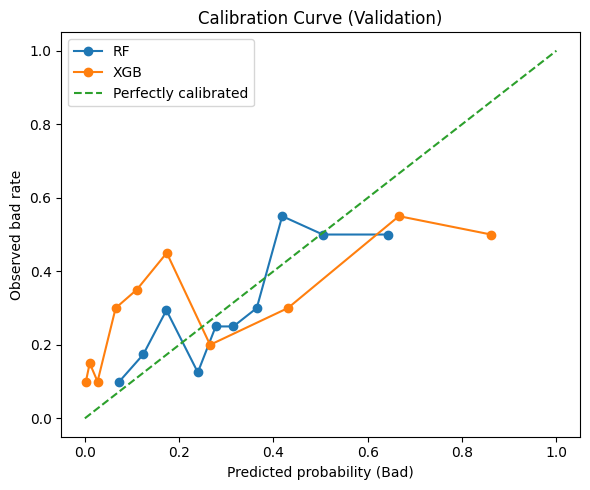

In [32]:
# Calibration(확률 기반 정책이면 강력)
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# --- rerun-safe guards ---
if "rf_val_proba" not in globals():
    rf_val_proba = rf_model.predict_proba(X_val)[:, 1]
if "xgb_val_proba" not in globals():
    xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]

# 1) Brier score (VAL)
rf_brier = brier_score_loss(y_val, rf_val_proba)
xgb_brier = brier_score_loss(y_val, xgb_val_proba)

print("Brier score (lower is better)")
print("RF :", rf_brier)
print("XGB:", xgb_brier)

# 2) Calibration curve (VAL)
rf_prob_true, rf_prob_pred = calibration_curve(y_val, rf_val_proba, n_bins=10, strategy="quantile")
xgb_prob_true, xgb_prob_pred = calibration_curve(y_val, xgb_val_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(6,5))
plt.plot(rf_prob_pred, rf_prob_true, marker="o", label="RF")
plt.plot(xgb_prob_pred, xgb_prob_true, marker="o", label="XGB")
plt.plot([0,1], [0,1], linestyle="--", label="Perfectly calibrated")
plt.xlabel("Predicted probability (Bad)")
plt.ylabel("Observed bad rate")
plt.title("Calibration Curve (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# Calibration 적용 후 확률 보정 -> 보정 후 Brier가 내려가면 "확률 기반 정책 안정성"을 기대할 수 있음
from sklearn.calibration import CalibratedClassifierCV

# 이미 학습된 pipeline을 그대로 사용하되, calibration은 train 기반 CV로 fit하는게 일반적
rf_cal = CalibratedClassifierCV(rf_model, method="isotonic", cv=3)
xgb_cal = CalibratedClassifierCV(xgb_model, method="isotonic", cv=3)

rf_cal.fit(X_train, y_train)
xgb_cal.fit(X_train, y_train)

rf_val_proba_cal = rf_cal.predict_proba(X_val)[:, 1]
xgb_val_proba_cal = xgb_cal.predict_proba(X_val)[:, 1]

print("Brier score (calibrated)")
print("RF :", brier_score_loss(y_val, rf_val_proba_cal))
print("XGB:", brier_score_loss(y_val, xgb_val_proba_cal))

C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\3173244738.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X.groupby(self.group_keys)[col]
C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\3173244738.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X.groupby(self.group_keys)[col]
C:\Users\lsy\AppData\Local\Temp\ipykernel_17620\3173244738.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X.groupby(self.group_key

Brier score (calibrated)
RF : 0.18964924824957927
XGB: 0.18733889459962547


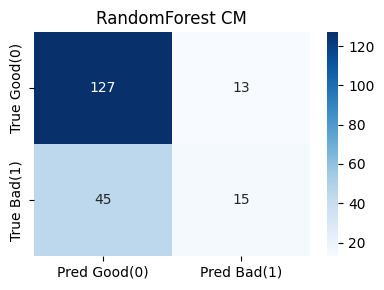

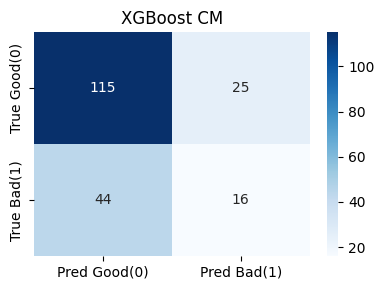

In [34]:
# Confusion Matrix (Bad 중심 비교)
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)  # labels: [0(good),1(bad)]
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred Good(0)","Pred Bad(1)"],
                yticklabels=["True Good(0)","True Bad(1)"])
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cm(y_test, rf_test_pred, "RandomForest CM")
plot_cm(y_test, xgb_test_pred, "XGBoost CM")

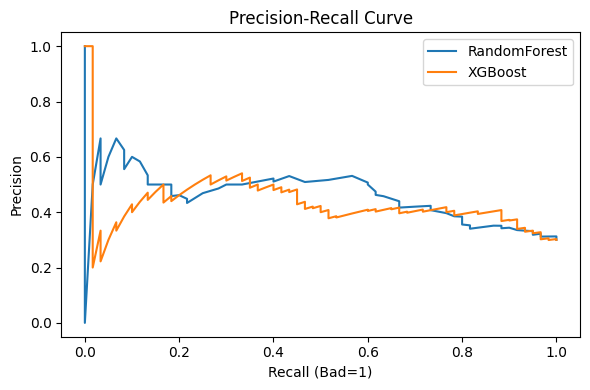

In [35]:
# PR Curve
rf_precision, rf_recall, _ = precision_recall_curve(y_val, rf_val_proba)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_val, xgb_val_proba)

plt.figure(figsize=(6,4))
plt.plot(rf_recall, rf_precision, label="RandomForest")
plt.plot(xgb_recall, xgb_precision, label="XGBoost")
plt.xlabel("Recall (Bad=1)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

- 낮은 Recall 구간에서는 RF가 Precision이 높음
- Recall을 올리면 XGB가 더 안정적

- 전체 정확도는 RandomForest가 더 높았지만, 부실 고객 탐지(Recall) 성능은 XGBoost가 더 우수했다. 신용 승인 정책에서는 Bad를 승인하는 오류가 가장 치명적이므로, 우리는 Accuracy보다 Bad Recall을 우선 기준으로 모델을 평가했다.

- 모델 선택/threshold 최적화는 validation에서만 수행하고, test는 최종 1회 성능 확인에만 사용.

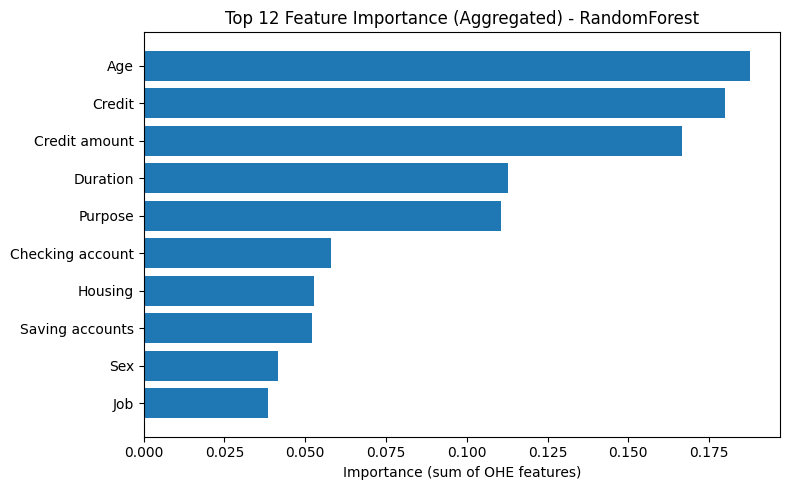

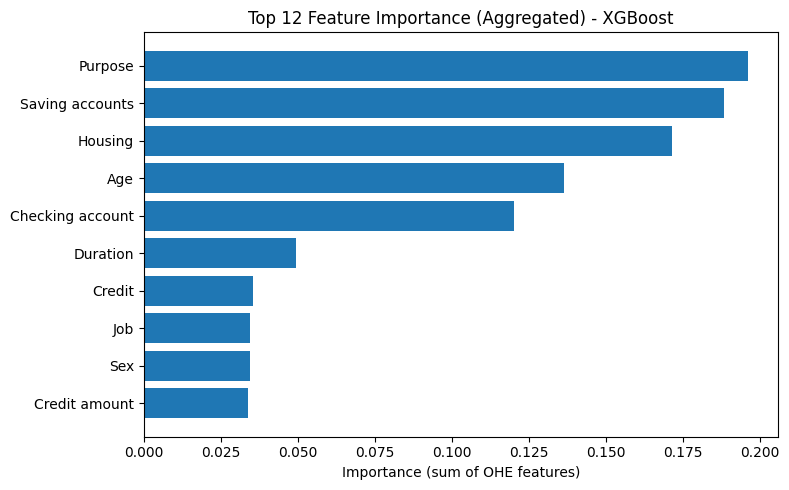

In [72]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("assets/project-a-images", exist_ok=True)

def get_feature_names_from_preprocessor(preprocessor, categorical_cols, numeric_cols):
    """
    ColumnTransformer + OneHotEncoder에서 최종 feature name을 복원
    """
    ohe = preprocessor.named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(categorical_cols)
    num_names = np.array(numeric_cols, dtype=object)
    return np.concatenate([cat_names, num_names])

def plot_top_feature_importance(model_pipeline, model_name, categorical_cols, numeric_cols, top_n=15,
                                outpath="assets/project-a-images/feature_importance.png"):
    """
    Pipeline( imputer -> preprocess -> model ) 에서
    - OHE 이후 feature importance를 구하고
    - 원본 카테고리 피처별로 합산(aggregation)해서 해석 가능하게 만든 뒤
    - Top N bar chart 저장
    """
    pre = model_pipeline.named_steps["preprocess"]
    model = model_pipeline.named_steps["model"]

    # 1) OHE 이후 feature names
    feature_names = get_feature_names_from_preprocessor(pre, categorical_cols, numeric_cols)

    # 2) importance 가져오기 (RF/XGB 모두 feature_importances_ 제공)
    if not hasattr(model, "feature_importances_"):
        raise ValueError(f"{model_name} has no feature_importances_. Consider permutation importance.")
    importances = model.feature_importances_

    fi = pd.DataFrame({"feature": feature_names, "importance": importances})

    # 3) 해석 쉽게: 원본 컬럼 단위로 aggregation
    #    예: Purpose_car, Purpose_radio/TV → Purpose 로 합치기
    def base_feature(f):
        # OneHotEncoder는 "col_value" 형태로 나오는 경우가 많음
        # (get_feature_names_out 결과는 "Purpose_car" 같은 형태)
        return f.split("_")[0] if "_" in f else f

    fi["base_feature"] = fi["feature"].apply(base_feature)
    agg = fi.groupby("base_feature", as_index=False)["importance"].sum().sort_values("importance", ascending=False)

    # 4) Plot Top N
    top = agg.head(top_n).copy()
    plt.figure(figsize=(8, 5))
    plt.barh(top["base_feature"][::-1], top["importance"][::-1])
    plt.title(f"Top {top_n} Feature Importance (Aggregated) - {model_name}")
    plt.xlabel("Importance (sum of OHE features)")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()

    return agg

# === 사용 예시 ===
rf_agg = plot_top_feature_importance(
    rf_model, "RandomForest",
    categorical_cols=categorical_cols,
    numeric_cols=numeric_cols,
    top_n=12,
    outpath="assets/project-a-images/step3_feature_importance_rf.png"
)

xgb_agg = plot_top_feature_importance(
    xgb_model, "XGBoost",
    categorical_cols=categorical_cols,
    numeric_cols=numeric_cols,
    top_n=12,
    outpath="assets/project-a-images/step3_feature_importance_xgb.png"
)

# (선택) 표도 저장해두면 나중에 해석 문장 쓰기 쉬움
rf_agg.to_csv("assets/project-a-images/step3_feature_importance_rf.csv", index=False)
xgb_agg.to_csv("assets/project-a-images/step3_feature_importance_xgb.csv", index=False)

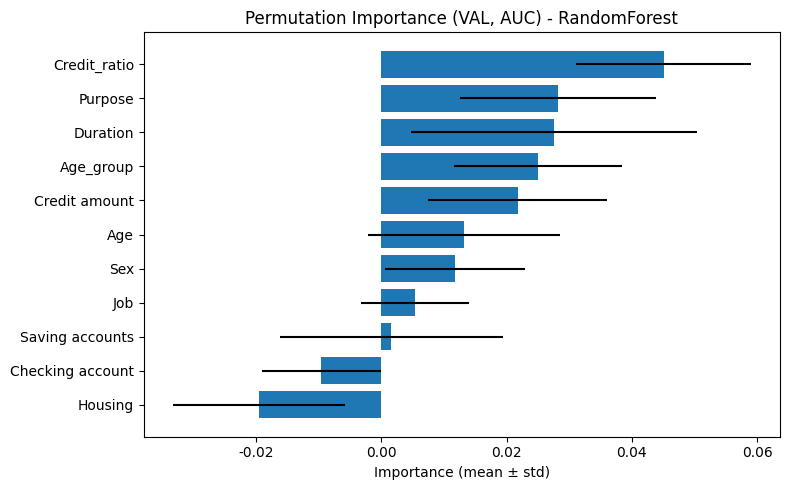

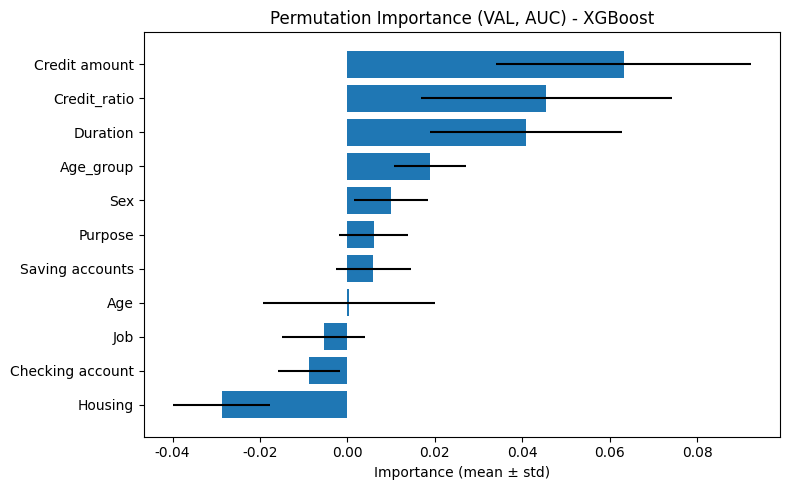

In [73]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(pipeline, X_val, y_val, model_name, top_n=12,
                                outpath="assets/project-a-images/step3_perm_importance.png"):
    """
    Permutation importance on raw X (pipeline이 내부에서 전처리)
    """
    r = permutation_importance(
        pipeline, X_val, y_val,
        n_repeats=10,
        random_state=42,
        scoring="roc_auc"   # 정책/리스크 관점에서 AUC도 괜찮음
    )

    perm = pd.DataFrame({
        "feature": X_val.columns,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False)

    top = perm.head(top_n).copy()

    plt.figure(figsize=(8,5))
    plt.barh(top["feature"][::-1], top["importance_mean"][::-1], xerr=top["importance_std"][::-1])
    plt.title(f"Permutation Importance (VAL, AUC) - {model_name}")
    plt.xlabel("Importance (mean ± std)")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()

    return perm

rf_perm = plot_permutation_importance(
    rf_model, X_val, y_val, "RandomForest",
    outpath="assets/project-a-images/step3_perm_importance_rf.png"
)

xgb_perm = plot_permutation_importance(
    xgb_model, X_val, y_val, "XGBoost",
    outpath="assets/project-a-images/step3_perm_importance_xgb.png"
)

In [79]:
print(type(perm))

<class 'type'>


In [82]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    rf_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

In [83]:
perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.head()

,feature,importance_mean,importance_std
10,Credit_ratio,0.045054,0.013973
8,Purpose,0.028173,0.015688
7,Duration,0.027560,0.022764
9,Age_group,0.024982,0.013462
6,Credit amount,0.021732,0.014283


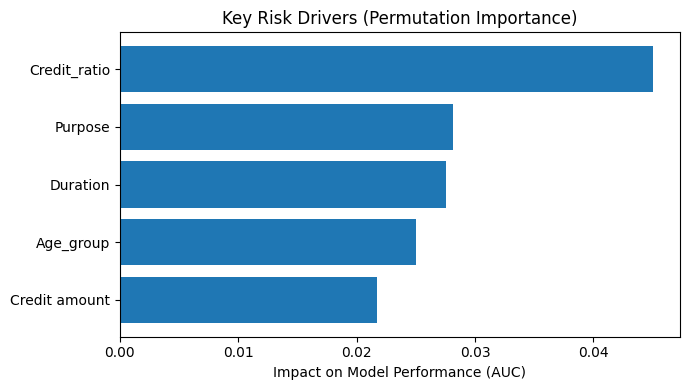

In [87]:
top = perm_df.head(5)

plt.figure(figsize=(7,4))
plt.barh(top["feature"], top["importance_mean"])
plt.gca().invert_yaxis()

plt.title("Key Risk Drivers (Permutation Importance)")
plt.xlabel("Impact on Model Performance (AUC)")

plt.tight_layout()

plt.savefig(
    "assets/project-a-images/step3_perm_importance_rf.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## step 3-2) RF vs XGB

proba >= threshold → Bad (Reject)
proba < threshold  → Good (Approve)

- Threshold 낮추면 → 더 많이 거절 → Bad Recall ↑
- Threshold 높이면 → 더 많이 승인 → 승인율 ↑

In [36]:
# Threshold 함수 정의

def evaluate_threshold(y_true, proba, threshold):
    y_pred = (proba >= threshold).astype(int)

    # confusion matrix 요소
    TP = ((y_pred == 1) & (y_true == 1)).sum() # bad correctly rejected
    TN = ((y_pred == 0) & (y_true == 0)).sum() # good correctly rejected
    FP = ((y_pred == 1) & (y_true == 0)).sum() # good correctly rejected
    FN = ((y_pred == 0) & (y_true == 1)).sum() # bad correctly rejected

    bad_recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    approval_rate = (y_pred == 0).mean()

    return bad_recall, approval_rate, TP, FP, FN

In [37]:
# Threshold Sweep 실행
thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for t in thresholds:
    rf_bad_recall, rf_approval, *_ = evaluate_threshold(y_val, rf_val_proba, t)
    xgb_bad_recall, xgb_approval, *_ = evaluate_threshold(y_val, xgb_val_proba, t)

    results.append({
        "threshold": t,
        "rf_bad_recall": rf_bad_recall,
        "rf_approval": rf_approval,
        "xgb_bad_recall": xgb_bad_recall,
        "xgb_approval": xgb_approval
    })

results_df = pd.DataFrame(results)
results_df.head()

,threshold,rf_bad_recall,rf_approval,xgb_bad_recall,xgb_approval
0,0.10,0.966667,0.100,0.766667,0.425
1,0.15,0.883333,0.225,0.666667,0.520
2,0.20,0.816667,0.300,0.516667,0.590
3,0.25,0.783333,0.390,0.483333,0.650
4,0.30,0.666667,0.520,0.466667,0.670


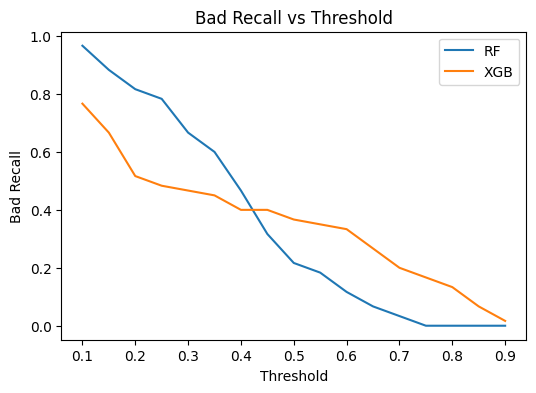

In [38]:
# bad recall 비교
plt.figure(figsize=(6,4))
plt.plot(results_df["threshold"], results_df["rf_bad_recall"], label="RF")
plt.plot(results_df["threshold"], results_df["xgb_bad_recall"], label="XGB")
plt.xlabel("Threshold")
plt.ylabel("Bad Recall")
plt.title("Bad Recall vs Threshold")
plt.legend()
plt.show()

- 낮은 threshold에서는 RF가 더 공격적으로 Bad를 막는다.
- 중간 threshold(0.4~0.6)에서는 XGB가 더 안정적이다. 

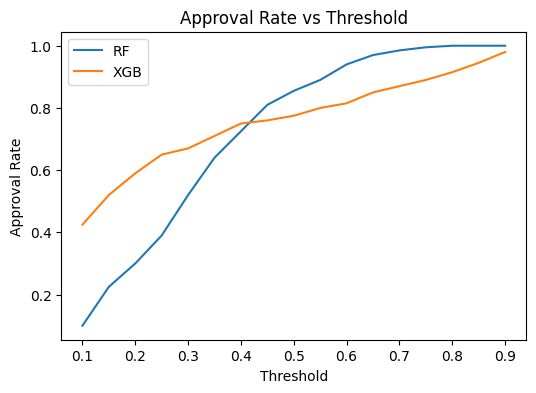

In [39]:
# 승인율 비교
plt.figure(figsize=(6,4))
plt.plot(results_df["threshold"], results_df["rf_approval"], label="RF")
plt.plot(results_df["threshold"], results_df["xgb_approval"], label="XGB")
plt.xlabel("Threshold")
plt.ylabel("Approval Rate")
plt.title("Approval Rate vs Threshold")
plt.legend()
plt.show()

- RF는 변동폭이 매우 큰만큼 정책 민감도가 높다. 그에 비해, XGB는 점진적으로 증가하며, 곡선이 매끄러움

- 이번 손익 가정(gain=1, loss=5)과 승인율 가드레일(≥60%) 하에서는 RF가 더 높은 Expected Profit과 더 낮은 Bad Approval Rate를 보여 운영 후보로 선정되었다.
- 다만 XGB는 threshold 변화에 따른 곡선이 더 매끄러운 편이어서, 손익 가정(loss/gain)이 달라질 경우 최적 모델이 바뀔 수 있다(→ loss sweep으로 확인).

## step4) 모델 성능을 “손익(KPI)”로 번역

가정 설정 (비즈니스 모델 단순화)
- EX) 승인 1건당 평균 이익 = +1 , 승인 1건당 평균 이익 = +1
- Expected Profit = (승인 건수 × 1) − (부실 승인 건수 × 5)

여기서 Expected Profit은 모델 예측을 실제 돈의 관점으로 환산한 시뮬레이션 결과

In [40]:
# Expected Profit 계산 함수

def evaluate_profit(y_true, proba, threshold, gain=1, loss=5):
    y_pred = (proba >= threshold).astype(int)

    # 승인 = 예측 good(0)
    approved = (y_pred == 0)

    total_approved = approved.sum()
    bad_approved = ((y_true == 1) & approved).sum()

    expected_profit = total_approved * gain - bad_approved * loss

    return total_approved, bad_approved, expected_profit

In [41]:
# Threshold Sweep (Profit 포함)

profit_results = []

for t in thresholds:
    rf_app, rf_bad_app, rf_profit = evaluate_profit(y_val, rf_val_proba, t)
    xgb_app, xgb_bad_app, xgb_profit = evaluate_profit(y_val, xgb_val_proba, t)

    profit_results.append({
        "threshold": t,
        "rf_profit": rf_profit,
        "xgb_profit": xgb_profit
    })

profit_df = pd.DataFrame(profit_results)
profit_df.head()

,threshold,rf_profit,xgb_profit
0,0.10,10,15
1,0.15,10,4
2,0.20,5,-27
3,0.25,13,-25
4,0.30,4,-26


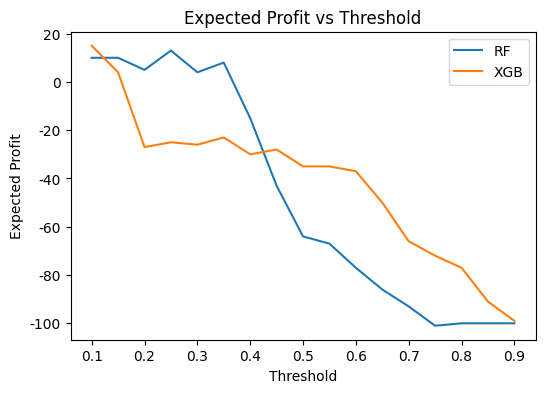

In [42]:
# Profit 곡선 시각화
plt.figure(figsize=(6,4))
plt.plot(profit_df["threshold"], profit_df["rf_profit"], label="RF")
plt.plot(profit_df["threshold"], profit_df["xgb_profit"], label="XGB")
plt.xlabel("Threshold")
plt.ylabel("Expected Profit")
plt.title("Expected Profit vs Threshold")
plt.legend()
plt.show()

위의 예시에 따라서 부실 1건이 승인 5건을 날려버린다는 가정에서, 모델이 공격적으로 거절할수록 유리한 구조가 된다.

그래서 하나의 모델이 좋다 나쁘다 라기보단, 손익 구조에 따라 최적 모델이 달라진다.

- 이번 손익 가정(gain=1, loss=5)에서는 RF가 낮은 threshold뿐 아니라 중간 구간(threshold 0.25~0.35)에서도 Expected Profit이 양수로 나타났다.
- 반면 XGB는 낮은 threshold(예: 0.10)에서만 이익이 나고, 승인율 가드레일을 적용하면 손익이 더 불리해졌다.
- 결론: “모델 우열”이 아니라, 손익 구조와 운영 제약(승인율 가드레일)에 따라 최적 정책이 달라진다.

RF는 수익 최고점이 낮은 threshold(=승인율 극단적으로 낮음) 쪽에 있는데 그러면 승인율이나 다른 요소를 반영하면 threshold가 어떻게 되는지 궁금해짐.

## step 4-2) 운영 제약을 넣은 threshold

In [43]:
# results_df에 approval / recall 있고, profit_df에 profit 있음 가정
merged = results_df.merge(profit_df, on="threshold", how="inner")

# 운영 제약 조정
min_approval = 0.80

cand = merged[merged["rf_approval"] >= min_approval].copy()
best_rf = cand.loc[cand["rf_profit"].idxmax(), ["threshold","rf_approval","rf_bad_recall","rf_profit"]]

cand = merged[merged["xgb_approval"] >= min_approval].copy()
best_xgb = cand.loc[cand["xgb_profit"].idxmax(), ["threshold","xgb_approval","xgb_bad_recall","xgb_profit"]]

print("✅ Best RF under approval>=0.80")
print(best_rf)

print("\n✅ Best XGB under approval>=0.80")
print(best_xgb)

✅ Best RF under approval>=0.80
threshold         0.450000
rf_approval       0.810000
rf_bad_recall     0.316667
rf_profit       -43.000000
Name: 7, dtype: float64

✅ Best XGB under approval>=0.80
threshold          0.55
xgb_approval       0.80
xgb_bad_recall     0.35
xgb_profit       -35.00
Name: 9, dtype: float64


In [44]:
# results_df에 approval / recall 있고, profit_df에 profit 있음 가정
merged = results_df.merge(profit_df, on="threshold", how="inner")

# 운영 제약 조정
min_approval = 0.60

cand = merged[merged["rf_approval"] >= min_approval].copy()
best_rf = cand.loc[cand["rf_profit"].idxmax(), ["threshold","rf_approval","rf_bad_recall","rf_profit"]]

cand = merged[merged["xgb_approval"] >= min_approval].copy()
best_xgb = cand.loc[cand["xgb_profit"].idxmax(), ["threshold","xgb_approval","xgb_bad_recall","xgb_profit"]]

print("✅ Best RF under approval>=0.60")
print(best_rf)

print("\n✅ Best XGB under approval>=0.60")
print(best_xgb)

✅ Best RF under approval>=0.60
threshold        0.35
rf_approval      0.64
rf_bad_recall    0.60
rf_profit        8.00
Name: 5, dtype: float64

✅ Best XGB under approval>=0.60
threshold          0.35
xgb_approval       0.71
xgb_bad_recall     0.45
xgb_profit       -23.00
Name: 5, dtype: float64


In [45]:
# results_df에 approval / recall 있고, profit_df에 profit 있음 가정
merged = results_df.merge(profit_df, on="threshold", how="inner")

# 운영 제약 조정
min_approval = 0.40

cand = merged[merged["rf_approval"] >= min_approval].copy()
best_rf = cand.loc[cand["rf_profit"].idxmax(), ["threshold","rf_approval","rf_bad_recall","rf_profit"]]

cand = merged[merged["xgb_approval"] >= min_approval].copy()
best_xgb = cand.loc[cand["xgb_profit"].idxmax(), ["threshold","xgb_approval","xgb_bad_recall","xgb_profit"]]

print("✅ Best RF under approval>=0.40")
print(best_rf)

print("\n✅ Best XGB under approval>=0.40")
print(best_xgb)

✅ Best RF under approval>=0.40
threshold        0.35
rf_approval      0.64
rf_bad_recall    0.60
rf_profit        8.00
Name: 5, dtype: float64

✅ Best XGB under approval>=0.40
threshold          0.100000
xgb_approval       0.425000
xgb_bad_recall     0.766667
xgb_profit        15.000000
Name: 0, dtype: float64


Threshold sweep 결과, Expected Profit은 모델과 threshold 조합에 따라 크게 달라졌다.

특히 부실 승인 손실을 크게 가정할수록 더 보수적인 정책(Reject 증가)이 유리한 구조가 나타났다.

## step 5) KPI Tree + 최적 Threshold + A/B테스트 설계

In [46]:
# 1) KPT Tree

# 가정(위와 동일)
GAIN_PER_APPROVAL = 1 # 승인 1건당 기대 이익
LOSS_PER_BAD_APPROVAL = 5 # 부실 승인 1건당 기대 손실 (LGD 반영한 손실 가정)

def print_kpi_tree(gain=GAIN_PER_APPROVAL, loss=LOSS_PER_BAD_APPROVAL):
    tree = f"""
KPI TREE (Decision System)
- North Star: Expected Profit (or Expected Loss 최소화)
  * Expected Profit = (Approved Count × {gain}) − (Bad Approved Count × {loss})
- Primary KPI:
  * Bad Approval Rate (= Bad approved / Approved)
  * Approval Rate (= Approved / Total)
- Supporting:
  * Bad Recall (= Bad detected / Total Bad)
  * Precision (Bad)
- Guardrails:
  * Application→Approval Conversion Drop
  * Underwriting Lead Time Increase
  * CS / Complaint Increase
"""
    print(tree)

print_kpi_tree()


KPI TREE (Decision System)
- North Star: Expected Profit (or Expected Loss 최소화)
  * Expected Profit = (Approved Count × 1) − (Bad Approved Count × 5)
- Primary KPI:
  * Bad Approval Rate (= Bad approved / Approved)
  * Approval Rate (= Approved / Total)
- Supporting:
  * Bad Recall (= Bad detected / Total Bad)
  * Precision (Bad)
- Guardrails:
  * Application→Approval Conversion Drop
  * Underwriting Lead Time Increase
  * CS / Complaint Increase



In [47]:
# 2) Threshold별 KPI계산 (RF/XGB 공통)
# - result_df: threshold, *_bad_recall, *_approval
# - profit_df: threshold, *_profit

merged = results_df.merge(profit_df, on="threshold", how="inner").copy()

# 승인수/부실승인수도 같이 계산해서 KPI Tree와 직접 연결
def compute_detail_metrics(y_true, proba, thresholds, gain=GAIN_PER_APPROVAL, loss=LOSS_PER_BAD_APPROVAL):
    rows = []
    y_true = np.array(y_true).astype(int)

    for t in thresholds:
        y_pred = (proba >= t).astype(int)  # 1=bad(reject), 0=good(approve)
        approved = (y_pred == 0)

        total = len(y_true)
        approved_cnt = approved.sum()
        bad_approved_cnt = ((y_true == 1) & approved).sum()
        bad_detected = ((y_true == 1) & (y_pred == 1)).sum()
        total_bad = (y_true == 1).sum()

        approval_rate = approved_cnt / total
        bad_recall = bad_detected / total_bad if total_bad > 0 else 0
        bad_approval_rate = bad_approved_cnt / approved_cnt if approved_cnt > 0 else np.nan

        exp_profit = approved_cnt * gain - bad_approved_cnt * loss
        exp_profit_per_approval = exp_profit / approved_cnt if approved_cnt > 0 else np.nan

        rows.append({
            "threshold": t,
            "approved_cnt": approved_cnt,
            "bad_approved_cnt": bad_approved_cnt,
            "approval_rate": approval_rate,
            "bad_recall": bad_recall,
            "bad_approval_rate": bad_approval_rate,
            "expected_profit": exp_profit,
            "expected_profit_per_approval": exp_profit_per_approval
        })

    return pd.DataFrame(rows)

rf_detail = compute_detail_metrics(y_val, rf_val_proba, merged["threshold"].values)
xgb_detail = compute_detail_metrics(y_val, xgb_val_proba, merged["threshold"].values)

rf_detail = rf_detail.add_prefix("rf_")
xgb_detail = xgb_detail.add_prefix("xgb_")

detail = pd.concat([rf_detail, xgb_detail.drop(columns=["xgb_threshold"])], axis=1)
detail.rename(columns={"rf_threshold":"threshold"}, inplace=True)

In [48]:
# 3) 운영 제약(승인율) 하 최적 Threshold 자동 도출
def best_under_approval(df, model_prefix, min_approval=0.6, objective="expected_profit"):
    # objective: expected_profit 또는 expected_profit_per_approval 등
    appr_col = f"{model_prefix}_approval_rate"
    obj_col = f"{model_prefix}_{objective}"

    feasible = df[df[appr_col] >= min_approval].copy()
    if feasible.empty:
        return None

    best_row = feasible.loc[feasible[obj_col].idxmax()]
    cols = ["threshold",
            f"{model_prefix}_approval_rate",
            f"{model_prefix}_bad_recall",
            f"{model_prefix}_bad_approval_rate",
            f"{model_prefix}_approved_cnt",
            f"{model_prefix}_bad_approved_cnt",
            f"{model_prefix}_expected_profit",
            f"{model_prefix}_expected_profit_per_approval"]
    return best_row[cols]

approval_constraints = [0.40, 0.60, 0.80]
summary_rows = []

for c in approval_constraints:
    best_rf = best_under_approval(detail, "rf", min_approval=c)
    best_xgb = best_under_approval(detail, "xgb", min_approval=c)
    summary_rows.append({
        "min_approval": c,
        "best_rf_threshold": None if best_rf is None else float(best_rf["threshold"]),
        "best_rf_profit": None if best_rf is None else float(best_rf["rf_expected_profit"]),
        "best_rf_bad_recall": None if best_rf is None else float(best_rf["rf_bad_recall"]),
        "best_xgb_threshold": None if best_xgb is None else float(best_xgb["threshold"]),
        "best_xgb_profit": None if best_xgb is None else float(best_xgb["xgb_expected_profit"]),
        "best_xgb_bad_recall": None if best_xgb is None else float(best_xgb["xgb_bad_recall"]),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n Best thresholds under approval constraints")
print(summary_df)



 Best thresholds under approval constraints
   min_approval  best_rf_threshold  best_rf_profit  best_rf_bad_recall  \
0           0.4               0.35             8.0            0.600000   
1           0.6               0.35             8.0            0.600000   
2           0.8               0.45           -43.0            0.316667   

   best_xgb_threshold  best_xgb_profit  best_xgb_bad_recall  
0                0.10             15.0             0.766667  
1                0.35            -23.0             0.450000  
2                0.55            -35.0             0.350000  


In [49]:
# 승인율 제약 0.60 기준으로 최종 운영 후보 선택(예시)
MIN_APPROVAL_FOR_LAUNCH = 0.60
best_rf_launch = best_under_approval(detail, "rf", min_approval=MIN_APPROVAL_FOR_LAUNCH)
best_xgb_launch = best_under_approval(detail, "xgb", min_approval=MIN_APPROVAL_FOR_LAUNCH)

print(f"\n Launch candidate under approval >= {MIN_APPROVAL_FOR_LAUNCH}")
print("\n[RF]")
print(best_rf_launch)
print("\n[XGB]")
print(best_xgb_launch)


 Launch candidate under approval >= 0.6

[RF]
threshold                            0.3500
rf_approval_rate                     0.6400
rf_bad_recall                        0.6000
rf_bad_approval_rate                 0.1875
rf_approved_cnt                    128.0000
rf_bad_approved_cnt                 24.0000
rf_expected_profit                   8.0000
rf_expected_profit_per_approval      0.0625
Name: 5, dtype: float64

[XGB]
threshold                             0.350000
xgb_approval_rate                     0.710000
xgb_bad_recall                        0.450000
xgb_bad_approval_rate                 0.232394
xgb_approved_cnt                    142.000000
xgb_bad_approved_cnt                 33.000000
xgb_expected_profit                 -23.000000
xgb_expected_profit_per_approval     -0.161972
Name: 5, dtype: float64


In [50]:
# 손익 가정 민감도 분석(loss sweep)

GAIN = 1.0
LOSS_LIST = [3, 5, 8, 10]
MIN_APPROVAL = 0.60

def recompute_profit_cols(detail_df: pd.DataFrame, gain: float, loss: float) -> pd.DataFrame:
    df = detail_df.copy()
    for pref in ["rf", "xgb"]:
        df[f"{pref}_expected_profit_tmp"] = df[f"{pref}_approved_cnt"] * gain - df[f"{pref}_bad_approved_cnt"] * loss
        df[f"{pref}_expected_profit_per_approval_tmp"] = (
            df[f"{pref}_expected_profit_tmp"] / df[f"{pref}_approved_cnt"].replace(0, np.nan)
        )
    return df

def pick_best_under_approval(df: pd.DataFrame, pref: str, min_approval: float, obj_col: str) -> pd.Series | None:
    appr = f"{pref}_approval_rate"
    feasible = df[df[appr] >= min_approval].copy()
    if feasible.empty:
        return None
    return feasible.loc[feasible[obj_col].idxmax()]

rows = []
for loss in LOSS_LIST:
    tmp = recompute_profit_cols(detail, gain=GAIN, loss=loss)

    best_rf = pick_best_under_approval(tmp, "rf", MIN_APPROVAL, "rf_expected_profit_tmp")
    best_xgb = pick_best_under_approval(tmp, "xgb", MIN_APPROVAL, "xgb_expected_profit_tmp")

    # 추천 모델 선택 (VAL 기준 expected_profit)
    if best_rf is None and best_xgb is None:
        continue
    if best_xgb is None or (best_rf is not None and best_rf["rf_expected_profit_tmp"] >= best_xgb["xgb_expected_profit_tmp"]):
        chosen = "RF"
        chosen_thr = float(best_rf["threshold"])
        chosen_profit = float(best_rf["rf_expected_profit_tmp"])
        chosen_badr = float(best_rf["rf_bad_recall"])
        chosen_bad_appr = float(best_rf["rf_bad_approval_rate"])
        chosen_appr = float(best_rf["rf_approval_rate"])
    else:
        chosen = "XGB"
        chosen_thr = float(best_xgb["threshold"])
        chosen_profit = float(best_xgb["xgb_expected_profit_tmp"])
        chosen_badr = float(best_xgb["xgb_bad_recall"])
        chosen_bad_appr = float(best_xgb["xgb_bad_approval_rate"])
        chosen_appr = float(best_xgb["xgb_approval_rate"])

    rows.append({
        "loss_per_bad_approval": loss,
        "chosen_model": chosen,
        "chosen_threshold": chosen_thr,
        "approval_rate": chosen_appr,
        "bad_recall": chosen_badr,
        "bad_approval_rate": chosen_bad_appr,
        "expected_profit": chosen_profit
    })

loss_sensitivity_df = pd.DataFrame(rows)
loss_sensitivity_df

,loss_per_bad_approval,chosen_model,chosen_threshold,approval_rate,bad_recall,bad_approval_rate,expected_profit
0,3,RF,0.35,0.64,0.6,0.1875,56.0
1,5,RF,0.35,0.64,0.6,0.1875,8.0
2,8,RF,0.35,0.64,0.6,0.1875,-64.0
3,10,RF,0.35,0.64,0.6,0.1875,-112.0


- 부실 승인 손실(Loss)이 커질수록, 정책은 더 보수적인 방향(Reject 증가)으로 이동하며 최적 threshold가 변합니다.
- 따라서 “어떤 모델이 무조건 더 좋다”가 아니라, 손익 구조와 운영 제약(승인율 가드레일)에 따라 최적 모델/threshold가 달라질 수 있습니다.

In [51]:
# One-line auto summary from loss sweep
if "loss_sensitivity_df" in globals() and not loss_sensitivity_df.empty:
    print("Loss sweep summary (min approval constraint applied):")
    display(loss_sensitivity_df)

Loss sweep summary (min approval constraint applied):


,loss_per_bad_approval,chosen_model,chosen_threshold,approval_rate,bad_recall,bad_approval_rate,expected_profit
0,3,RF,0.35,0.64,0.6,0.1875,56.0
1,5,RF,0.35,0.64,0.6,0.1875,8.0
2,8,RF,0.35,0.64,0.6,0.1875,-64.0
3,10,RF,0.35,0.64,0.6,0.1875,-112.0


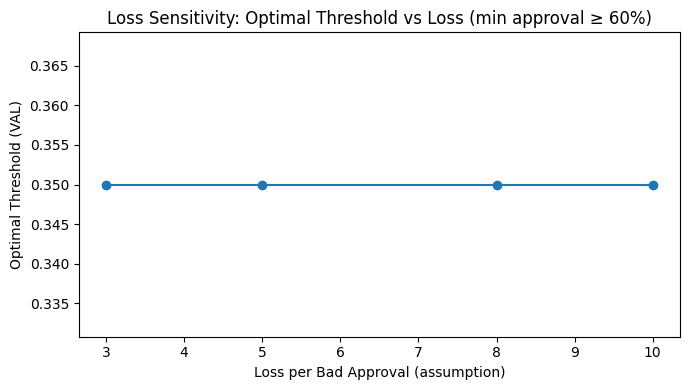

In [52]:
# 시각화
plt.figure(figsize=(7,4))
plt.plot(loss_sensitivity_df["loss_per_bad_approval"], loss_sensitivity_df["chosen_threshold"], marker="o")
plt.xlabel("Loss per Bad Approval (assumption)")
plt.ylabel("Optimal Threshold (VAL)")
plt.title(f"Loss Sensitivity: Optimal Threshold vs Loss (min approval ≥ {MIN_APPROVAL:.0%})")
plt.tight_layout()
plt.show()

이론적으로 부실 승인 손실(Loss)이 커질수록 정책은 더 보수적인 방향(Reject 증가)으로 이동할 가능성이 있다.

그러나 본 데이터와 승인율 가드레일(≥60%) 조건에서는
loss 3~10 범위에서도 최적 threshold가 0.35로 유지되었다.

이는 해당 정책이 손익 가정 변화에 대해 비교적 견고(robust)하다는 것을 의미한다.

운영 제약(승인율 ≥60%)을 적용하여 후보 정책을 비교한 결과,
RandomForest + threshold 0.35 조합이 가장 높은 Expected Profit을 보였다.

해당 정책의 주요 KPI는 다음과 같다.

Approval Rate: 0.64  
Bad Recall: 0.60  
Bad Approval Rate: 0.1875  
Expected Profit: +8

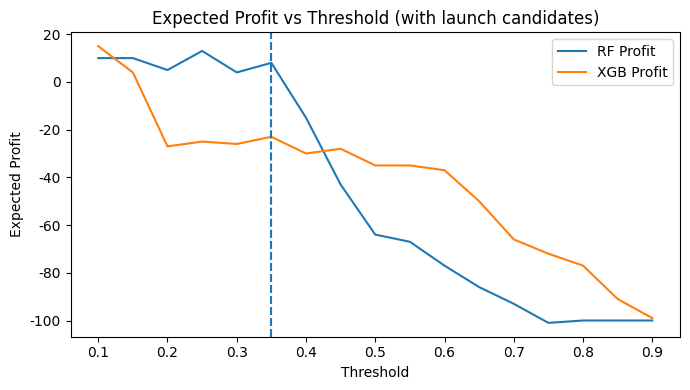

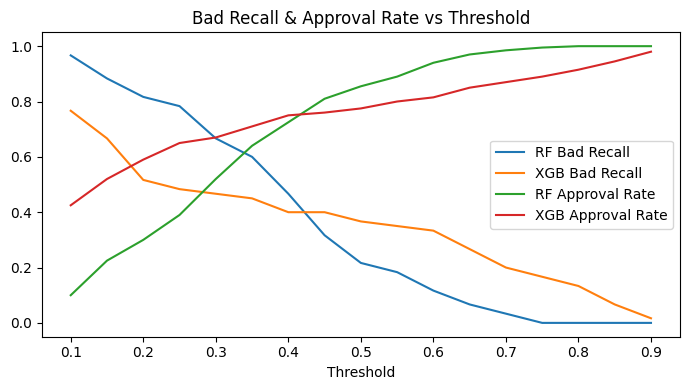

In [53]:
# 4) KPI 시각화(운영 의사결정용)
# - Threshold vs Expected Profit
# - Threshold vs (Bad Recall, Approval Rate)

plt.figure(figsize=(7,4))
plt.plot(detail["threshold"], detail["rf_expected_profit"], label="RF Profit")
plt.plot(detail["threshold"], detail["xgb_expected_profit"], label="XGB Profit")
plt.axvline(best_rf_launch["threshold"], linestyle="--")
plt.axvline(best_xgb_launch["threshold"], linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Expected Profit")
plt.title("Expected Profit vs Threshold (with launch candidates)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(detail["threshold"], detail["rf_bad_recall"], label="RF Bad Recall")
plt.plot(detail["threshold"], detail["xgb_bad_recall"], label="XGB Bad Recall")
plt.plot(detail["threshold"], detail["rf_approval_rate"], label="RF Approval Rate")
plt.plot(detail["threshold"], detail["xgb_approval_rate"], label="XGB Approval Rate")
plt.xlabel("Threshold")
plt.title("Bad Recall & Approval Rate vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

- Final TEST 1-shot

In [54]:
# Final evaluation on TEST (only once)
# (model/threshold are chosen on VALIDATION under approval constraint)

MIN_APPROVAL_FOR_LAUNCH = 0.60

# best candidates were computed on VAL in Step5
best_rf_launch = best_under_approval(detail, "rf", min_approval=MIN_APPROVAL_FOR_LAUNCH)
best_xgb_launch = best_under_approval(detail, "xgb", min_approval=MIN_APPROVAL_FOR_LAUNCH)

# Choose model on VAL objective (expected_profit)
if best_rf_launch["rf_expected_profit"] >= best_xgb_launch["xgb_expected_profit"]:
    CHOSEN_MODEL = "RF"
    CHOSEN_T = float(best_rf_launch["threshold"])
else:
    CHOSEN_MODEL = "XGB"
    CHOSEN_T = float(best_xgb_launch["threshold"])

print("Chosen on VAL:", CHOSEN_MODEL, CHOSEN_T)

# 1-shot evaluation on TEST
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

test_proba = rf_test_proba if CHOSEN_MODEL == "RF" else xgb_test_proba

test_kpi = compute_detail_metrics(y_test, test_proba, [CHOSEN_T])
print("\nFinal TEST KPI (1-shot):")
print(test_kpi)

Chosen on VAL: RF 0.3500000000000001

Final TEST KPI (1-shot):
   threshold  approved_cnt  bad_approved_cnt  approval_rate  bad_recall  \
0       0.35           119                34          0.595    0.433333   

   bad_approval_rate  expected_profit  expected_profit_per_approval  
0           0.285714              -51                     -0.428571  


- 정책 후보는 Validation에서 **승인율 가드레일(≥ 60%)**을 만족하는 구간에서 Expected Profit을 최대화하는 조합으로 선택했습니다.
- 결론적으로 모델은 “정답을 맞추는 도구”가 아니라, 운영 가능한 컷오프(Threshold)를 설계하기 위한 확률 추정기로 사용했습니다.

모델 선택과 threshold 최적화는 Validation 데이터에서만 수행하고,
Test 데이터는 최종 1회 성능 확인(1-shot evaluation)에만 사용하였다.

Test set에서는 Expected Profit이 음수로 나타났는데,
이는 손익 가정의 단순화와 데이터 샘플 분산의 영향을 받을 수 있다.

따라서 실제 정책 적용 시에는
즉시 전면 도입이 아니라 A/B 테스트 기반 단계적 검증이 필요하다.

In [55]:
# 5) A/B테스트 설계 산출물
def ab_test_plan(model_name, threshold, min_approval, primary="Bad Approval Rate", secondary=None, guardrails=None):
    if secondary is None:
        secondary = ["Approval Rate", "Expected Profit per Approval"]
    if guardrails is None:
        guardrails = ["Application→Approval conversion", "Underwriting lead time", "CS/complaints"]

    plan = {
        "Experiment": "Credit Policy A/B Test",
        "Control(A)": "Current policy (rule-based / existing model)",
        "Treatment(B)": f"{model_name} + threshold={threshold:.2f} (reject if proba>=t)",
        "Traffic Split": "20% Treatment / 80% Control (start small; rollout if stable)",
        "Duration": "8–12 weeks (minimum to observe early delinquency signals)",
        "Primary KPI": primary,
        "Secondary KPIs": ", ".join(secondary),
        "Guardrails": ", ".join(guardrails),
        "Rollout": "20% → 50% → 100% (if guardrails OK and primary KPI improves)"
    }
    return plan

# 기본 추천: 승인율 제약 하에서 더 “운영 친화적인” 후보를 선택
# - 예시로 approval>=0.60 기준 profit이 더 큰 모델 선택
chosen = None
if best_rf_launch["rf_expected_profit"] >= best_xgb_launch["xgb_expected_profit"]:
    chosen = ("RandomForest", float(best_rf_launch["threshold"]))
else:
    chosen = ("XGBoost", float(best_xgb_launch["threshold"]))

plan = ab_test_plan(chosen[0], chosen[1], MIN_APPROVAL_FOR_LAUNCH)

print("\nA/B Test Plan (draft)")
for k, v in plan.items():
    print(f"- {k}: {v}")



A/B Test Plan (draft)
- Experiment: Credit Policy A/B Test
- Control(A): Current policy (rule-based / existing model)
- Treatment(B): RandomForest + threshold=0.35 (reject if proba>=t)
- Traffic Split: 20% Treatment / 80% Control (start small; rollout if stable)
- Duration: 8–12 weeks (minimum to observe early delinquency signals)
- Primary KPI: Bad Approval Rate
- Secondary KPIs: Approval Rate, Expected Profit per Approval
- Guardrails: Application→Approval conversion, Underwriting lead time, CS/complaints
- Rollout: 20% → 50% → 100% (if guardrails OK and primary KPI improves)


- Step2에서 만든 룰 기반 정책 컬럼(Credit_Rating 또는 Score)을 val subset에서 재현 가능해야 하므로 아래코드 추가 -> get_bad_approval_rate_at_threshold

- Control baseline(p1)은 A/B의 Control(A) 정책(현행 룰 기반)에서 산출해야 실험 설계가 일관됨.
- 샘플사이즈 산출은 실험 전 계획 단계이므로 test를 사용하지 않고 validation에서 추정.

In [56]:
# (옵션) 필요한 샘플사이즈(대략): Bad 승인율 감소 검정 (2-proportion z-test 근사)

from math import ceil, sqrt
from scipy.stats import norm

# ✅ 0) val_idx 먼저 정의
val_idx = X_val.index

# ✅ sanity check: ensure indices align
assert set(val_idx).issubset(set(df_imp.index)), \
    "df_imp index and X_val index mismatch. Check reset_index/dropna."

# NOTE: Control baseline uses the current rule-based policy computed on the same imputed features for fair comparison.

def sample_size_two_proportions(p1, p2, alpha=0.05, power=0.8):
    z_alpha = norm.ppf(1 - alpha/2)
    z_beta = norm.ppf(power)
    p_bar = (p1 + p2) / 2
    n = ((z_alpha * sqrt(2*p_bar*(1-p_bar)) + z_beta * sqrt(p1*(1-p1) + p2*(1-p2)))**2) / ((p1 - p2)**2)
    return ceil(n)

def get_bad_approval_rate_at_threshold(y_true, proba, threshold):
    # y_true: 1=bad, 0=good
    # y_pred=1 reject(bad), 0 approve(good)
    y_pred = (proba >= threshold).astype(int)
    approved = (y_pred == 0)
    if approved.sum() == 0:
        return np.nan
    bad_approved = ((np.array(y_true) == 1) & approved).sum()
    return bad_approved / approved.sum()

# Control baseline: current rule-based policy (VAL)
# def rule_policy_approve(df_scored):
#     return df_scored["Credit_Rating"].isin(["Medium", "High", "Very High"]).astype(int)

# def bad_approval_rate_from_policy(y_true_bad, approve_pred):
#     approved = (approve_pred == 1)
#     if approved.sum() == 0:
#         return np.nan
#     bad_approved = ((np.array(y_true_bad) == 1) & approved).sum()
#     return bad_approved / approved.sum()

# 1) p1: control baseline from rule-based policy on validation
df_val_policy = df_imp.loc[val_idx].copy()   # df_imp must include Credit_Rating
control_baseline = bad_approval_rate_from_policy(y_val, rule_policy_approve(df_val_policy))

# 2) treatment_rate: chosen model/threshold on validation (optional, for sanity)
# (rf_val_proba / xgb_val_proba가 먼저 계산되어 있어야 함)
if chosen[0] == "RandomForest":
    treatment_rate = get_bad_approval_rate_at_threshold(y_val, rf_val_proba, chosen[1])
else:
    treatment_rate = get_bad_approval_rate_at_threshold(y_val, xgb_val_proba, chosen[1])

print("\n[Sample size rough estimate for Bad Approval Rate reduction]")
print("Control bad approval rate (rule-based, VAL):", control_baseline)
print("Treatment bad approval rate (chosen model, VAL):", treatment_rate)

# 3) Sample size using MDE (relative 20% reduction)
MDE_REL = 0.20
TREATMENT_SHARE = 0.20

if pd.notna(control_baseline) and control_baseline > 0:
    target = max(1e-6, control_baseline * (1 - MDE_REL))
    n_per_group = sample_size_two_proportions(control_baseline, target, alpha=0.05, power=0.8)

    needed_total_inflow = ceil(n_per_group / TREATMENT_SHARE)

    print(f"✅ Needed sample size per group (approx): {n_per_group}")
    print(f"✅ Needed total inflow (given {int(TREATMENT_SHARE*100)}% treatment): {needed_total_inflow}")
    print("   (Note: rough z-test approximation; real rollout depends on delinquency lag & ops constraints.)")
else:
    print("⚠️ Could not estimate baseline reliably (approved_cnt==0 or NaN).")


[Sample size rough estimate for Bad Approval Rate reduction]
Control bad approval rate (rule-based, VAL): 0.375
Treatment bad approval rate (chosen model, VAL): 0.1875
✅ Needed sample size per group (approx): 623
✅ Needed total inflow (given 20% treatment): 3115
   (Note: rough z-test approximation; real rollout depends on delinquency lag & ops constraints.)


## step 5-2)입력값 기반 최적 Threshold + 총 필요 유입수 + 기간 산출

In [57]:
TREATMENT_SHARE = 0.20
needed_total_inflow = ceil(n_per_group / TREATMENT_SHARE)
print(needed_total_inflow)

3115


In [58]:
def sample_size_two_proportions(p1: float, p2: float, alpha: float = 0.05, power: float = 0.8) -> int:
    """
    2-proportion z-test 근사치로 '그룹당' 필요 샘플 수 계산.
    p1: control rate, p2: treatment rate
    """
    if not (0 < p1 < 1 and 0 < p2 < 1):
        raise ValueError(f"p1 and p2 must be between (0,1). got p1={p1}, p2={p2}")
    if p1 == p2:
        return 10**9  # practically infinite

    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    p_bar = (p1 + p2) / 2

    n = (
        (z_alpha * sqrt(2 * p_bar * (1 - p_bar)) + z_beta * sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
    ) / ((p1 - p2) ** 2)
    return int(ceil(n))


def choose_best_threshold_under_constraints(
    detail_df: pd.DataFrame,
    model_prefix: str,
    min_approval_rate: float,
    objective: str = "expected_profit",  # or "expected_profit_per_approval"
) -> pd.Series | None:
    """
    detail_df: threshold별 rf_* / xgb_* 컬럼을 가진 테이블
    model_prefix: "rf" 또는 "xgb"
    """
    appr_col = f"{model_prefix}_approval_rate"
    obj_col = f"{model_prefix}_{objective}"

    if appr_col not in detail_df.columns or obj_col not in detail_df.columns:
        missing = [c for c in [appr_col, obj_col] if c not in detail_df.columns]
        raise KeyError(f"Missing required columns: {missing}")

    feasible = detail_df[detail_df[appr_col] >= min_approval_rate].copy()
    if feasible.empty:
        return None

    best = feasible.loc[feasible[obj_col].idxmax()].copy()
    return best


def ab_feasibility_and_recommendation(
    detail_df: pd.DataFrame,
    stage_label: str = "VAL",
    min_approval_rate: float = 0.6,
    # 손익 가정
    gain_per_approval: float = 1.0,
    loss_per_bad_approval: float = 5.0,
    # 실험 운영 입력
    total_inflow: int = 6000,              # 총 유입 수 (실험 기간 동안)
    treatment_share: float = 0.2,          # Treatment 비중 (0.2면 20/80)
    approvals_capability_note: str = "N/A",
    # 샘플사이즈(검정) 입력
    alpha: float = 0.05,
    power: float = 0.8,
    mde_relative: float = 0.2,             # bad 승인율을 20% 줄이는 것을 탐지하고 싶다
    # ✅ NEW: control baseline rate from current policy (rule-based) estimated on VAL
    control_bad_approval_rate: float | None = None,
):
    """
    출력:
    - 운영 제약(min approval) 하에서 RF/XGB 각각 최적 threshold
    - 해당 threshold에서 기대 KPI
    - MDE 기준 그룹당 필요 샘플수 + 현재 트래픽/유입에서 가능한지

    중요:
    - detail_df는 'validation에서 계산한 threshold별 KPI 테이블'을 넣는 것을 권장합니다.
    - control_bad_approval_rate는 '현행 정책(룰 기반)'의 bad approval rate를 VAL에서 추정한 값으로 넣으세요.
    """

    if not (0 < treatment_share < 1):
        raise ValueError(f"treatment_share must be in (0,1). got {treatment_share}")
    if total_inflow <= 0:
        raise ValueError(f"total_inflow must be > 0. got {total_inflow}")
    if not (0 < min_approval_rate <= 1):
        raise ValueError(f"min_approval_rate must be in (0,1]. got {min_approval_rate}")

    # 0) 손익 가정 반영해서 expected_profit 재계산 (detail_df에 이미 있어도, 입력값으로 갱신)
    df = detail_df.copy()
    for pref in ["rf", "xgb"]:
        need_cols = [f"{pref}_approved_cnt", f"{pref}_bad_approved_cnt", f"{pref}_approval_rate",
                     f"{pref}_bad_recall", f"{pref}_bad_approval_rate"]
        missing = [c for c in need_cols if c not in df.columns]
        if missing:
            raise KeyError(f"detail_df missing required columns for {pref}: {missing}")

        df[f"{pref}_expected_profit"] = df[f"{pref}_approved_cnt"] * gain_per_approval - df[f"{pref}_bad_approved_cnt"] * loss_per_bad_approval
        df[f"{pref}_expected_profit_per_approval"] = df[f"{pref}_expected_profit"] / df[f"{pref}_approved_cnt"].replace(0, np.nan)

    # 1) 운영 제약 하 최적 threshold 선택
    best_rf = choose_best_threshold_under_constraints(df, "rf", min_approval_rate, objective="expected_profit")
    best_xgb = choose_best_threshold_under_constraints(df, "xgb", min_approval_rate, objective="expected_profit")

    if best_rf is None or best_xgb is None:
        return {"error": "No feasible threshold under the approval constraint."}

    # 2) 추천 모델(같은 제약 하에서 expected_profit 최대)
    rf_profit = float(best_rf["rf_expected_profit"])
    xgb_profit = float(best_xgb["xgb_expected_profit"])
    chosen = ("rf", best_rf) if rf_profit >= xgb_profit else ("xgb", best_xgb)

    # 3) A/B 샘플사이즈(그룹당) 추정: bad_approval_rate의 상대 mde 감소
    # ✅ control baseline은 '현행 정책(룰 기반)'에서 추정한 값을 입력으로 받는다
    if control_bad_approval_rate is None or not np.isfinite(control_bad_approval_rate) or control_bad_approval_rate <= 0:
        return {"error": "control_bad_approval_rate must be provided (rule-based baseline on VAL) and > 0."}

    p1 = float(control_bad_approval_rate)
    p2 = max(1e-6, p1 * (1 - mde_relative))
    n_per_group = sample_size_two_proportions(p1, p2, alpha=alpha, power=power)

    # 4) 현재 트래픽 비율에서 필요한 총 유입 수
    needed_total_inflow = int(ceil(n_per_group / treatment_share))

    # 5) 현재 계획(total_inflow)로 가능한지
    feasible_now = total_inflow >= needed_total_inflow

    # 6) 요약표 만들기
    def pack(pref: str, row: pd.Series, stage: str):
        return {
            "model": pref.upper(),
            "threshold": float(row["threshold"]),
            "approval_rate": float(row[f"{pref}_approval_rate"]),
            "bad_recall": float(row[f"{pref}_bad_recall"]),
            "bad_approval_rate": float(row[f"{pref}_bad_approval_rate"]),
            f"approved_cnt({stage})": int(row[f"{pref}_approved_cnt"]),
            f"bad_approved_cnt({stage})": int(row[f"{pref}_bad_approved_cnt"]),
            f"expected_profit({stage})": float(row[f"{pref}_expected_profit"]),
            f"expected_profit_per_approval({stage})": float(row[f"{pref}_expected_profit_per_approval"]),
        }

    rf_pack = pack("rf", best_rf, stage_label)
    xgb_pack = pack("xgb", best_xgb, stage_label)
    chosen_pack = pack(chosen[0], chosen[1], stage_label)

    return {
        "inputs": {
            "stage_label": stage_label,
            "min_approval_rate": min_approval_rate,
            "gain_per_approval": gain_per_approval,
            "loss_per_bad_approval": loss_per_bad_approval,
            "total_inflow_planned": total_inflow,
            "treatment_share": treatment_share,
            "alpha": alpha,
            "power": power,
            "mde_relative": mde_relative,
            "control_bad_approval_rate(rule-based)": p1,
            "ops_note": approvals_capability_note,
        },
        "best_rf": rf_pack,
        "best_xgb": xgb_pack,
        "recommended": chosen_pack,
        "ab_sample_size": {
            "control_rate_est(p1)": p1,
            "target_rate(p2)": p2,
            "needed_n_per_group": n_per_group,
            "needed_total_inflow_given_split": needed_total_inflow,
            "feasible_with_planned_inflow": feasible_now,
        },
    }

In [59]:
print("n_per_group exists?", "n_per_group" in globals())
print("needed_total_inflow exists?", "needed_total_inflow" in globals())

n_per_group exists? True
needed_total_inflow exists? True


In [60]:
result = ab_feasibility_and_recommendation(
    detail_df=detail,
    stage_label="VAL",
    min_approval_rate=0.60,
    gain_per_approval=1,
    loss_per_bad_approval=5,
    total_inflow=6000,
    treatment_share=0.20,
    alpha=0.05,
    power=0.80,
    mde_relative=0.20,
    control_bad_approval_rate=control_baseline
)

needed_total_inflow = result["ab_sample_size"]["needed_total_inflow_given_split"]
n_per_group = result["ab_sample_size"]["needed_n_per_group"]

In [61]:
n_per_group = result["ab_sample_size"]["needed_n_per_group"]
needed_total_inflow = result["ab_sample_size"]["needed_total_inflow_given_split"]

In [62]:
# detail: 우리가 만든 threshold별 KPI 테이블 (rf_* / xgb_* 포함)
# total_inflow: 실험 기간 동안 유입 총량 (예: 8주 동안 20,000건 유입이면 20000)

summary = {
    "Chosen model": CHOSEN_MODEL,
    "Chosen threshold": CHOSEN_T,
    "Control bad approval rate (VAL)": control_baseline,
    "Treatment bad approval rate (VAL)": treatment_rate,
    "Needed n per group": result["ab_sample_size"]["needed_n_per_group"],
    "Needed total inflow": result["ab_sample_size"]["needed_total_inflow_given_split"],
    "Feasible with planned inflow?": result["ab_sample_size"]["feasible_with_planned_inflow"],
}
summary

{'Chosen model': 'RF',
 'Chosen threshold': 0.3500000000000001,
 'Control bad approval rate (VAL)': np.float64(0.375),
 'Treatment bad approval rate (VAL)': np.float64(0.1875),
 'Needed n per group': 623,
 'Needed total inflow': 3115,
 'Feasible with planned inflow?': True}

In [63]:
print("result exists?", "result" in globals())
print(result.keys() if "result" in globals() else None)

result exists? True
dict_keys(['inputs', 'best_rf', 'best_xgb', 'recommended', 'ab_sample_size'])


In [64]:
print("\n[Recommended Threshold under constraints]")
print(result["recommended"])

print("\n[Best RF / Best XGB]")
print("RF:", result["best_rf"])
print("XGB:", result["best_xgb"])

print("\n[A/B sample size & feasibility]")
print(result["ab_sample_size"])


[Recommended Threshold under constraints]
{'model': 'RF', 'threshold': 0.3500000000000001, 'approval_rate': 0.64, 'bad_recall': 0.6, 'bad_approval_rate': 0.1875, 'approved_cnt(VAL)': 128, 'bad_approved_cnt(VAL)': 24, 'expected_profit(VAL)': 8.0, 'expected_profit_per_approval(VAL)': 0.0625}

[Best RF / Best XGB]
RF: {'model': 'RF', 'threshold': 0.3500000000000001, 'approval_rate': 0.64, 'bad_recall': 0.6, 'bad_approval_rate': 0.1875, 'approved_cnt(VAL)': 128, 'bad_approved_cnt(VAL)': 24, 'expected_profit(VAL)': 8.0, 'expected_profit_per_approval(VAL)': 0.0625}
XGB: {'model': 'XGB', 'threshold': 0.3500000000000001, 'approval_rate': 0.71, 'bad_recall': 0.45, 'bad_approval_rate': 0.2323943661971831, 'approved_cnt(VAL)': 142, 'bad_approved_cnt(VAL)': 33, 'expected_profit(VAL)': -23.0, 'expected_profit_per_approval(VAL)': -0.1619718309859155}

[A/B sample size & feasibility]
{'control_rate_est(p1)': 0.375, 'target_rate(p2)': 0.30000000000000004, 'needed_n_per_group': 623, 'needed_total_infl

In [65]:
# Final TEST 1-shot evaluation for the chosen model/threshold
chosen_model = result["recommended"]["model"]  # 'RF' or 'XGB'
chosen_t = float(result["recommended"]["threshold"])

rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
test_proba = rf_test_proba if chosen_model == "RF" else xgb_test_proba

test_kpi = compute_detail_metrics(y_test, test_proba, [chosen_t])  # 네가 이미 쓰는 함수
print("\n✅ Final TEST KPI (1-shot)")
print(test_kpi)


✅ Final TEST KPI (1-shot)
   threshold  approved_cnt  bad_approved_cnt  approval_rate  bad_recall  \
0       0.35           119                34          0.595    0.433333   

   bad_approval_rate  expected_profit  expected_profit_per_approval  
0           0.285714              -51                     -0.428571  


In [66]:
# Control vs Treatment comparison on VAL (policy-level lift)

# def rule_policy_approve(df_scored):
#     return df_scored["Credit_Rating"].isin(["Medium", "High", "Very High"]).astype(int)

# def policy_metrics_from_approve(y_true, approve_pred, gain=1.0, loss=5.0):
#     # y_true: 1=bad, 0=good
#     approved = (approve_pred == 1)
#     approved_cnt = approved.sum()
#     bad_approved_cnt = ((y_true == 1) & approved).sum()

#     approval_rate = approved_cnt / len(y_true)
#     bad_approval_rate = bad_approved_cnt / approved_cnt if approved_cnt else np.nan
#     expected_profit = approved_cnt * gain - bad_approved_cnt * loss
#     exp_profit_per_approval = expected_profit / approved_cnt if approved_cnt else np.nan

#     return {
#         "approval_rate": approval_rate,
#         "bad_approval_rate": bad_approval_rate,
#         "approved_cnt": int(approved_cnt),
#         "bad_approved_cnt": int(bad_approved_cnt),
#         "expected_profit": float(expected_profit),
#         "expected_profit_per_approval": float(exp_profit_per_approval),
#     }

# Control metrics (VAL)
val_idx = X_val.index
df_val_policy = df_imp.loc[val_idx].copy()
approve_rule_val = rule_policy_approve(df_val_policy)
control_metrics = policy_metrics_from_approve(y_val, approve_rule_val, gain=1, loss=5)

# Treatment metrics (VAL) - chosen model/threshold
chosen_model = result["recommended"]["model"]
chosen_t = float(result["recommended"]["threshold"])
val_proba = rf_val_proba if chosen_model == "RF" else xgb_val_proba
approve_treat_val = (val_proba < chosen_t).astype(int)  # approve if proba<threshold
treat_metrics = policy_metrics_from_approve(y_val, approve_treat_val, gain=1, loss=5)

lift_df = pd.DataFrame([control_metrics, treat_metrics], index=["Control(rule)", f"Treatment({chosen_model}@{chosen_t:.2f})"])
print("\n✅ Control vs Treatment (VAL)")
display(lift_df)

print("\n✅ Lift (Treatment - Control)")
display(lift_df.loc[f"Treatment({chosen_model}@{chosen_t:.2f})"] - lift_df.loc["Control(rule)"])


✅ Control vs Treatment (VAL)


,approval_rate,bad_approval_rate,approved_cnt,bad_approved_cnt,expected_profit,expected_profit_per_approval
Control(rule),0.68,0.3750,136,51,-119.0,-0.8750
Treatment(RF@0.35),0.64,0.1875,128,24,8.0,0.0625



✅ Lift (Treatment - Control)


approval_rate                    -0.0400
bad_approval_rate                -0.1875
approved_cnt                     -8.0000
bad_approved_cnt                -27.0000
expected_profit                 127.0000
expected_profit_per_approval      0.9375
dtype: float64

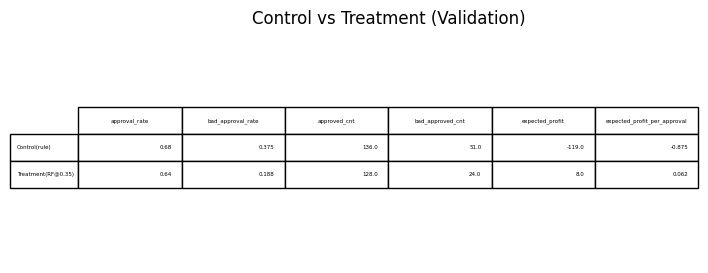

In [67]:
import matplotlib.pyplot as plt
import os

os.makedirs("assets/project-a-images", exist_ok=True)

fig, ax = plt.subplots(figsize=(8,3))
ax.axis('off')

table = ax.table(
    cellText=lift_df.round(3).values,
    colLabels=lift_df.columns,
    rowLabels=lift_df.index,
    loc='center'
)

table.scale(1,1.6)

plt.title("Control vs Treatment (Validation)", fontsize=12)

plt.savefig(
    "assets/project-a-images/step5_control_vs_treatment_val.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

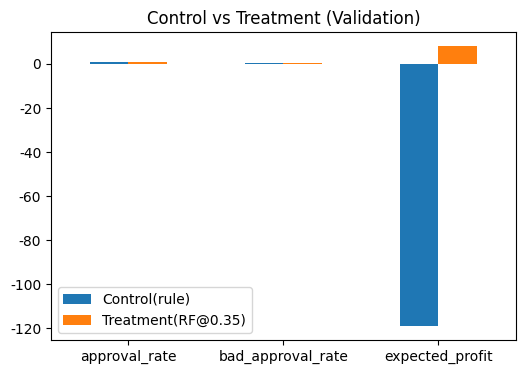

In [68]:
metrics = ["approval_rate","bad_approval_rate","expected_profit"]
compare = lift_df[metrics]

compare.T.plot(kind="bar", figsize=(6,4))
plt.title("Control vs Treatment (Validation)")
plt.xticks(rotation=0)

plt.savefig(
    "assets/project-a-images/step5_control_vs_treatment_val.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

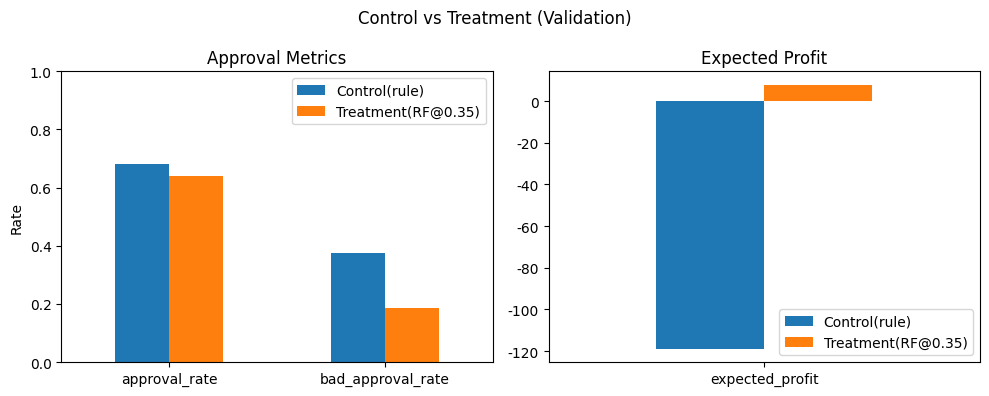

In [69]:
import matplotlib.pyplot as plt
import os

os.makedirs("assets/project-a-images", exist_ok=True)

fig, axes = plt.subplots(1,2, figsize=(10,4))

# 1️⃣ rate chart
rate_metrics = ["approval_rate","bad_approval_rate"]
lift_df[rate_metrics].T.plot(kind="bar", ax=axes[0])
axes[0].set_title("Approval Metrics")
axes[0].set_ylim(0,1)
axes[0].set_ylabel("Rate")
axes[0].tick_params(axis='x', rotation=0)

# 2️⃣ profit chart
profit_metrics = ["expected_profit"]
lift_df[profit_metrics].T.plot(kind="bar", ax=axes[1])
axes[1].set_title("Expected Profit")
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle("Control vs Treatment (Validation)", fontsize=12)

plt.tight_layout()

plt.savefig(
    "assets/project-a-images/step5_control_vs_treatment_val.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [71]:
# Translate lift into "per 1000 applications" on VAL
control_bad_appr = control_metrics["bad_approval_rate"]
treat_bad_appr = treat_metrics["bad_approval_rate"]

delta_bad_approval_rate = treat_bad_appr - control_bad_appr
print("\nPer-1000 impact (VAL):")
print("Δ Bad Approval Rate:", delta_bad_approval_rate)

# rough per 1000 approvals depends on approval rate; use approvals per 1000 apps
control_approvals_per_1000 = control_metrics["approval_rate"] * 1000
treat_approvals_per_1000 = treat_metrics["approval_rate"] * 1000

control_bad_approved_per_1000 = control_approvals_per_1000 * control_bad_appr
treat_bad_approved_per_1000 = treat_approvals_per_1000 * treat_bad_appr

print(f"Control bad approved per 1000 apps: {control_bad_approved_per_1000:.1f}")
print(f"Treatment bad approved per 1000 apps: {treat_bad_approved_per_1000:.1f}")
print(f"Δ bad approved per 1000 apps: {(treat_bad_approved_per_1000 - control_bad_approved_per_1000):.1f}")


Per-1000 impact (VAL):
Δ Bad Approval Rate: -0.1875
Control bad approved per 1000 apps: 255.0
Treatment bad approved per 1000 apps: 120.0
Δ bad approved per 1000 apps: -135.0


본 프로젝트의 핵심은 모델 정확도를 높이는 것이 아니라
손익 기반 의사결정 구조를 설계하는 것이었다.

모델은 단순히 정답을 맞추는 도구가 아니라,
운영 제약(승인율 가드레일)과 손익 구조를 고려하여
**실제 서비스에서 사용할 수 있는 컷오프(Threshold)를 설계하는 확률 추정기**로 활용되었다.